## **Data Cleaning & Processing**

In [ ]:
# ── Upload your data files ──────────────────────────────────
from google.colab import files

print("Upload all 5 files: _spx_d.xlsx, fedfundrate.xlsx, GDP.xlsx, inflation.xlsx, unemploy.xlsx")
uploaded = files.upload()

# Confirm what was uploaded
import os
print("\nFiles now available:")
for f in uploaded.keys():
    print(f"  ✓ {f}")

Upload all 5 files: _spx_d.xlsx, fedfundrate.xlsx, GDP.xlsx, inflation.xlsx, unemploy.xlsx


Saving GDP.xlsx to GDP (1).xlsx
Saving inflation.xlsx to inflation (1).xlsx
Saving unemploy.xlsx to unemploy (1).xlsx
Saving fedfundrate.xlsx to fedfundrate (1).xlsx
Saving ^spx_d.xlsx to ^spx_d (1).xlsx

Files now available:
  ✓ GDP (1).xlsx
  ✓ inflation (1).xlsx
  ✓ unemploy (1).xlsx
  ✓ fedfundrate (1).xlsx
  ✓ ^spx_d (1).xlsx


In [ ]:


import pandas as pd
import numpy as np
from scipy import stats

# ── Load data ──────────────────────────────────────────────────
def load_fred(path, sheet_index=1, col_rename=None):
    df = pd.read_excel(path, sheet_name=sheet_index, header=0)
    df.columns = ['date', col_rename]
    df['date'] = pd.to_datetime(df['date'])
    return df.set_index('date').sort_index()

spx_raw = pd.read_excel('^spx_d.xlsx', index_col=0, parse_dates=True)
spx_raw.index.name = 'date'
spx_raw   = spx_raw.sort_index()

fed_raw   = load_fred('fedfundrate.xlsx', col_rename='fed_rate')
gdp_raw   = load_fred('GDP.xlsx',         col_rename='gdp')
inf_raw   = load_fred('inflation.xlsx',   col_rename='inflation')
unemp_raw = load_fred('unemploy.xlsx',    col_rename='unemployment')

print("Raw shapes:")
print(f"  SPX: {spx_raw.shape} | Fed: {fed_raw.shape} | GDP: {gdp_raw.shape}")
print(f"  Inflation: {inf_raw.shape} | Unemployment: {unemp_raw.shape}")

# ── Remove duplicates ──────────────────────────────────────────
for df in [spx_raw, fed_raw, gdp_raw, inf_raw, unemp_raw]:
    df = df[~df.index.duplicated()]

# ── Align all to SPX trading-day calendar ─────────────────────
# GDP (quarterly) and macro (monthly) → forward fill to daily
# Fed Rate (daily incl. weekends) → reindex to trading days only
trading_days = spx_raw.index

fed_daily   = fed_raw.reindex(trading_days, method='ffill')
gdp_daily   = gdp_raw.reindex(trading_days, method='ffill')
inf_daily   = inf_raw.reindex(trading_days, method='ffill')
unemp_daily = unemp_raw.reindex(trading_days, method='ffill')

# ── Missing values BEFORE fill ────────────────────────────────
print("\nMissing values before cleaning:")
for name, s in [('Fed Rate', fed_daily), ('GDP', gdp_daily),
                ('Inflation', inf_daily), ('Unemployment', unemp_daily)]:
    n = s.isna().sum().sum()
    print(f"  {name}: {n} missing ({n/len(s)*100:.1f}%)")

# ── Fill remaining NaN ────────────────────────────────────────
for df in [fed_daily, gdp_daily, inf_daily, unemp_daily]:
    df.ffill(inplace=True)
    df.bfill(inplace=True)

# SPX → time interpolation for any gaps
spx_clean = spx_raw.copy().interpolate(method='time')

print("\nMissing values after cleaning:")
for name, s in [('SPX', spx_clean), ('Fed Rate', fed_daily),
                ('GDP', gdp_daily), ('Inflation', inf_daily),
                ('Unemployment', unemp_daily)]:
    print(f"  {name}: {s.isna().sum().sum()} NaN remaining")

# ── Merge into master DataFrame ───────────────────────────────
master = spx_clean.copy()
master.columns = ['open', 'high', 'low', 'close', 'volume']
master['fed_rate']     = fed_daily['fed_rate']
master['gdp']          = gdp_daily['gdp']
master['inflation']    = inf_daily['inflation']
master['unemployment'] = unemp_daily['unemployment']

print(f"\nMaster DataFrame: {master.shape}")
print(f"Date range: {master.index[0].date()} → {master.index[-1].date()}")
print(master.head(3))

# ── Outlier detection (Z-score, document only — do NOT delete) ─
print("\nOutlier detection (|z-score| > 3):")
for col in ['close', 'volume', 'fed_rate', 'inflation', 'unemployment']:
    z = np.abs(stats.zscore(master[col].dropna()))
    print(f"  {col}: {(z > 3).sum()} outliers")

# NOTE: All outliers are KEPT — they reflect real economic events:
# • Unemployment spike to 14.8% (Apr 2020) = COVID-19 pandemic
# • Volume spikes = crisis panic selling / buying
# • Inflation peak ~6.5% (late 2022) = post-COVID supply shock
# • Fed Rate rapid rise 0.08% → 5.33% (2022–2023) = fastest tightening cycle
# Removing these would destroy the most analytically valuable periods.

Raw shapes:
  SPX: (2515, 5) | Fed: (3653, 1) | GDP: (41, 1)
  Inflation: (121, 1) | Unemployment: (121, 1)

Missing values before cleaning:
  Fed Rate: 0 missing (0.0%)
  GDP: 0 missing (0.0%)
  Inflation: 0 missing (0.0%)
  Unemployment: 23 missing (0.9%)

Missing values after cleaning:
  SPX: 0 NaN remaining
  Fed Rate: 0 NaN remaining
  GDP: 0 NaN remaining
  Inflation: 0 NaN remaining
  Unemployment: 0 NaN remaining

Master DataFrame: (2515, 9)
Date range: 2016-04-25 → 2026-04-24
               open     high      low    close        volume  fed_rate  \
date                                                                     
2016-04-25  2089.37  2089.37  2077.52  2087.79  1.844300e+09      0.37   
2016-04-26  2089.84  2096.87  2085.80  2091.70  1.976217e+09      0.37   
2016-04-27  2092.33  2099.89  2082.31  2095.15  2.277839e+09      0.37   

                  gdp  inflation  unemployment  
date                                            
2016-04-25  18711.702    2.53143         

## **Exploratory** **Data** **Analysis**

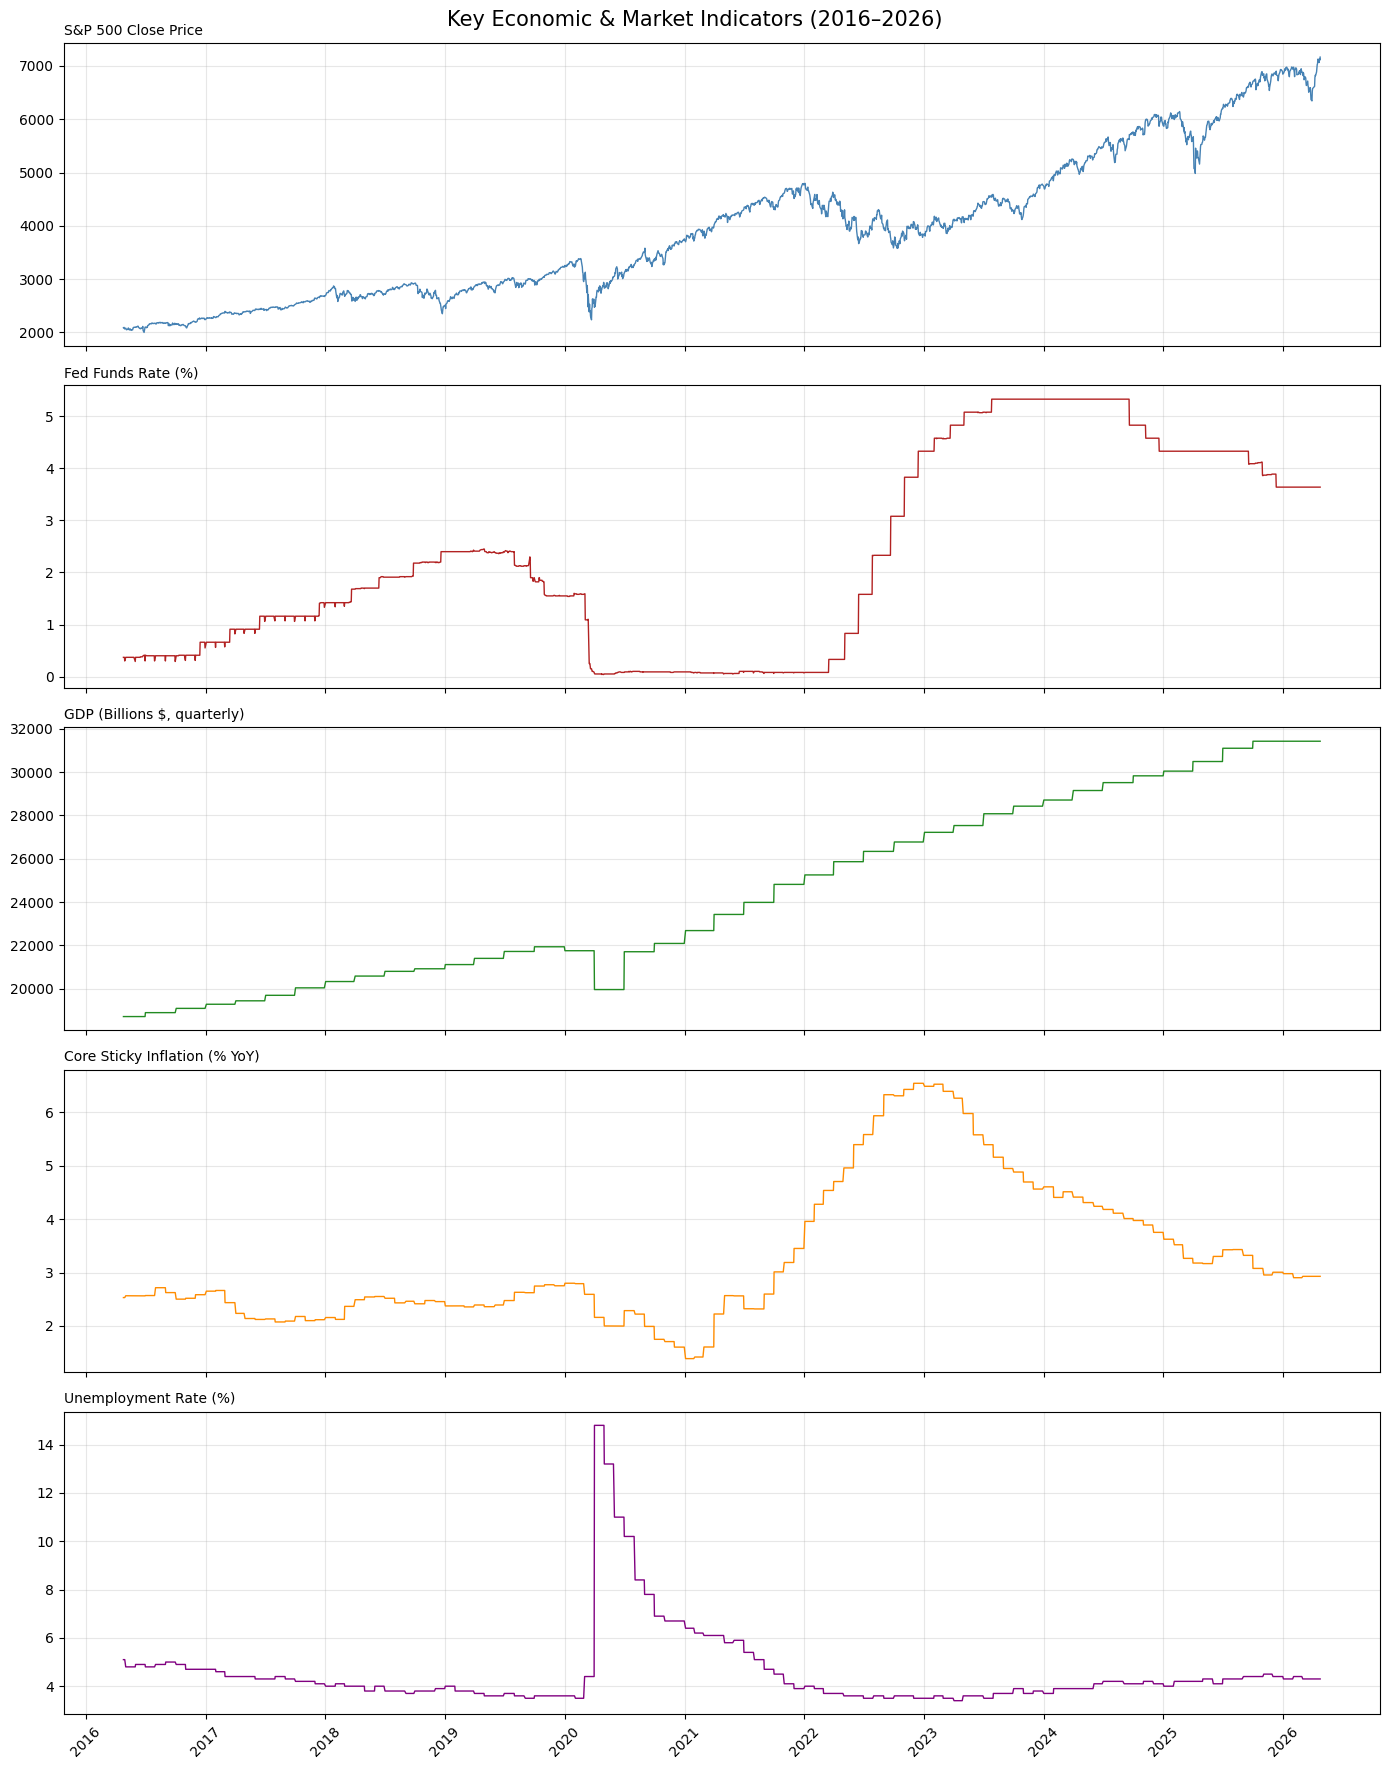

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Fig 1: Time-series of all 5 key indicators ────────────────
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
fig.suptitle('Key Economic & Market Indicators (2016–2026)', fontsize=15, y=0.98)

plot_config = [
    ('close',        'S&P 500 Close Price',          'steelblue'),
    ('fed_rate',     'Fed Funds Rate (%)',            'firebrick'),
    ('gdp',          'GDP (Billions $, quarterly)',   'forestgreen'),
    ('inflation',    'Core Sticky Inflation (% YoY)','darkorange'),
    ('unemployment', 'Unemployment Rate (%)',         'purple'),
]
for ax, (col, title, color) in zip(axes, plot_config):
    ax.plot(master.index, master[col], color=color, linewidth=1.0)
    ax.set_title(title, fontsize=10, loc='left')
    ax.grid(True, alpha=0.3)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

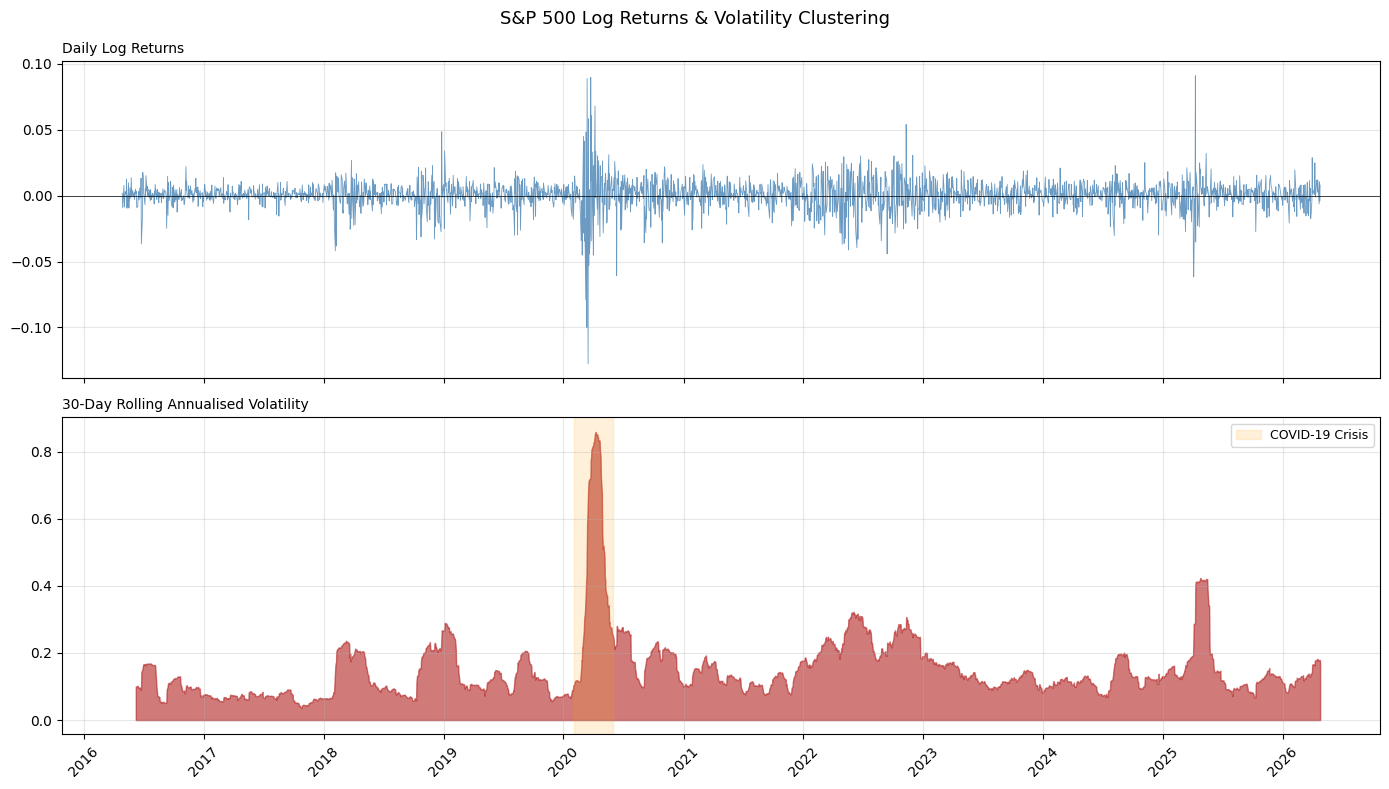

In [ ]:
# ── Fig 2: Log returns + 30-day rolling volatility ────────────
master['log_return'] = np.log(master['close'] / master['close'].shift(1))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('S&P 500 Log Returns & Volatility Clustering', fontsize=13)

axes[0].plot(master.index, master['log_return'], color='steelblue',
             linewidth=0.6, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Daily Log Returns', loc='left', fontsize=10)
axes[0].grid(True, alpha=0.3)

rolling_vol = master['log_return'].rolling(30).std() * np.sqrt(252)
axes[1].fill_between(master.index, rolling_vol, alpha=0.6, color='firebrick')
axes[1].axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'),
                alpha=0.15, color='orange', label='COVID-19 Crisis')
axes[1].set_title('30-Day Rolling Annualised Volatility', loc='left', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

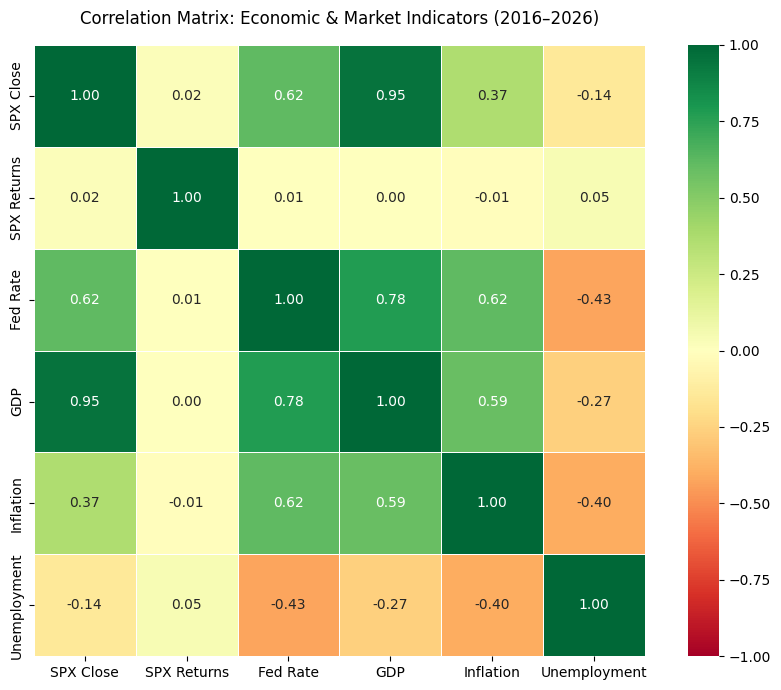

In [ ]:
# ── Fig 3: Correlation heatmap ────────────────────────────────
corr_cols   = ['close', 'log_return', 'fed_rate', 'gdp', 'inflation', 'unemployment']
corr_labels = ['SPX Close', 'SPX Returns', 'Fed Rate', 'GDP', 'Inflation', 'Unemployment']
corr_matrix = master[corr_cols].dropna().corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax, square=True,
            annot_kws={'size': 10})
ax.set_title('Correlation Matrix: Economic & Market Indicators (2016–2026)', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

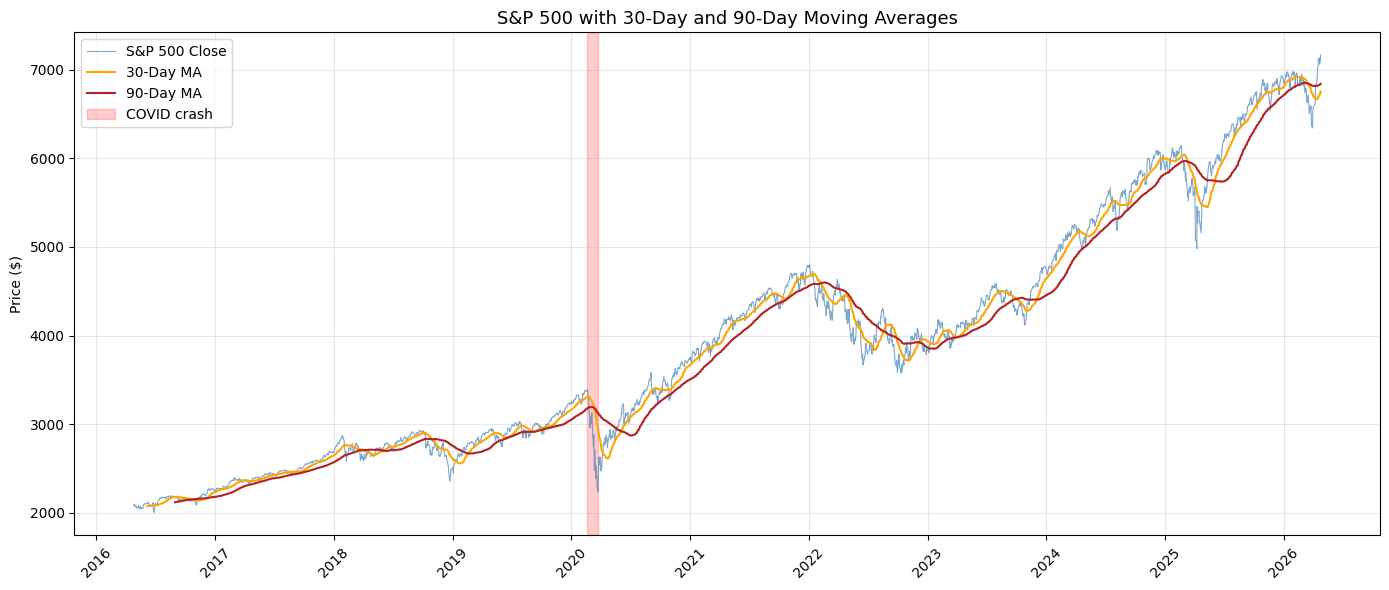

In [ ]:
# ── Fig 4: SPX with 30-day and 90-day moving averages ─────────
master['ma30'] = master['close'].rolling(30).mean()
master['ma90'] = master['close'].rolling(90).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(master.index, master['close'], color='steelblue', linewidth=0.8,
        alpha=0.7, label='S&P 500 Close')
ax.plot(master.index, master['ma30'], color='orange', linewidth=1.5, label='30-Day MA')
ax.plot(master.index, master['ma90'], color='firebrick', linewidth=1.5, label='90-Day MA')
ax.axvspan(pd.Timestamp('2020-02-19'), pd.Timestamp('2020-03-23'),
           alpha=0.2, color='red', label='COVID crash')
ax.set_title('S&P 500 with 30-Day and 90-Day Moving Averages', fontsize=13)
ax.set_ylabel('Price ($)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation 1 (Fig 1 & 2)**: COVID-19 Shock (Mar 2020) — SPX dropped ~34% in 5 weeks while unemployment spiked to 14.8%. Volatility clustering is clearly visible around this period.

**Observation 2 (Fig 3)**: Inflation and Fed Rate are strongly positively correlated(~+0.85), showing the Fed's reactive tightening policy during  2021 to 2023:

**Observation 3 (Fig 3)**: GDP and SPX Close are strongly positively correlated (~+0.90), but this breaks down in 2020 — the market recovered within months while GDP took over a year.

**Observation 4 (Fig 4)**: The 30-day MA crossing below the 90-day MA in March 2020 (death cross) was a reliable sell signal. The subsequent golden cross in mid-2020 confirmed the bull market recovery.

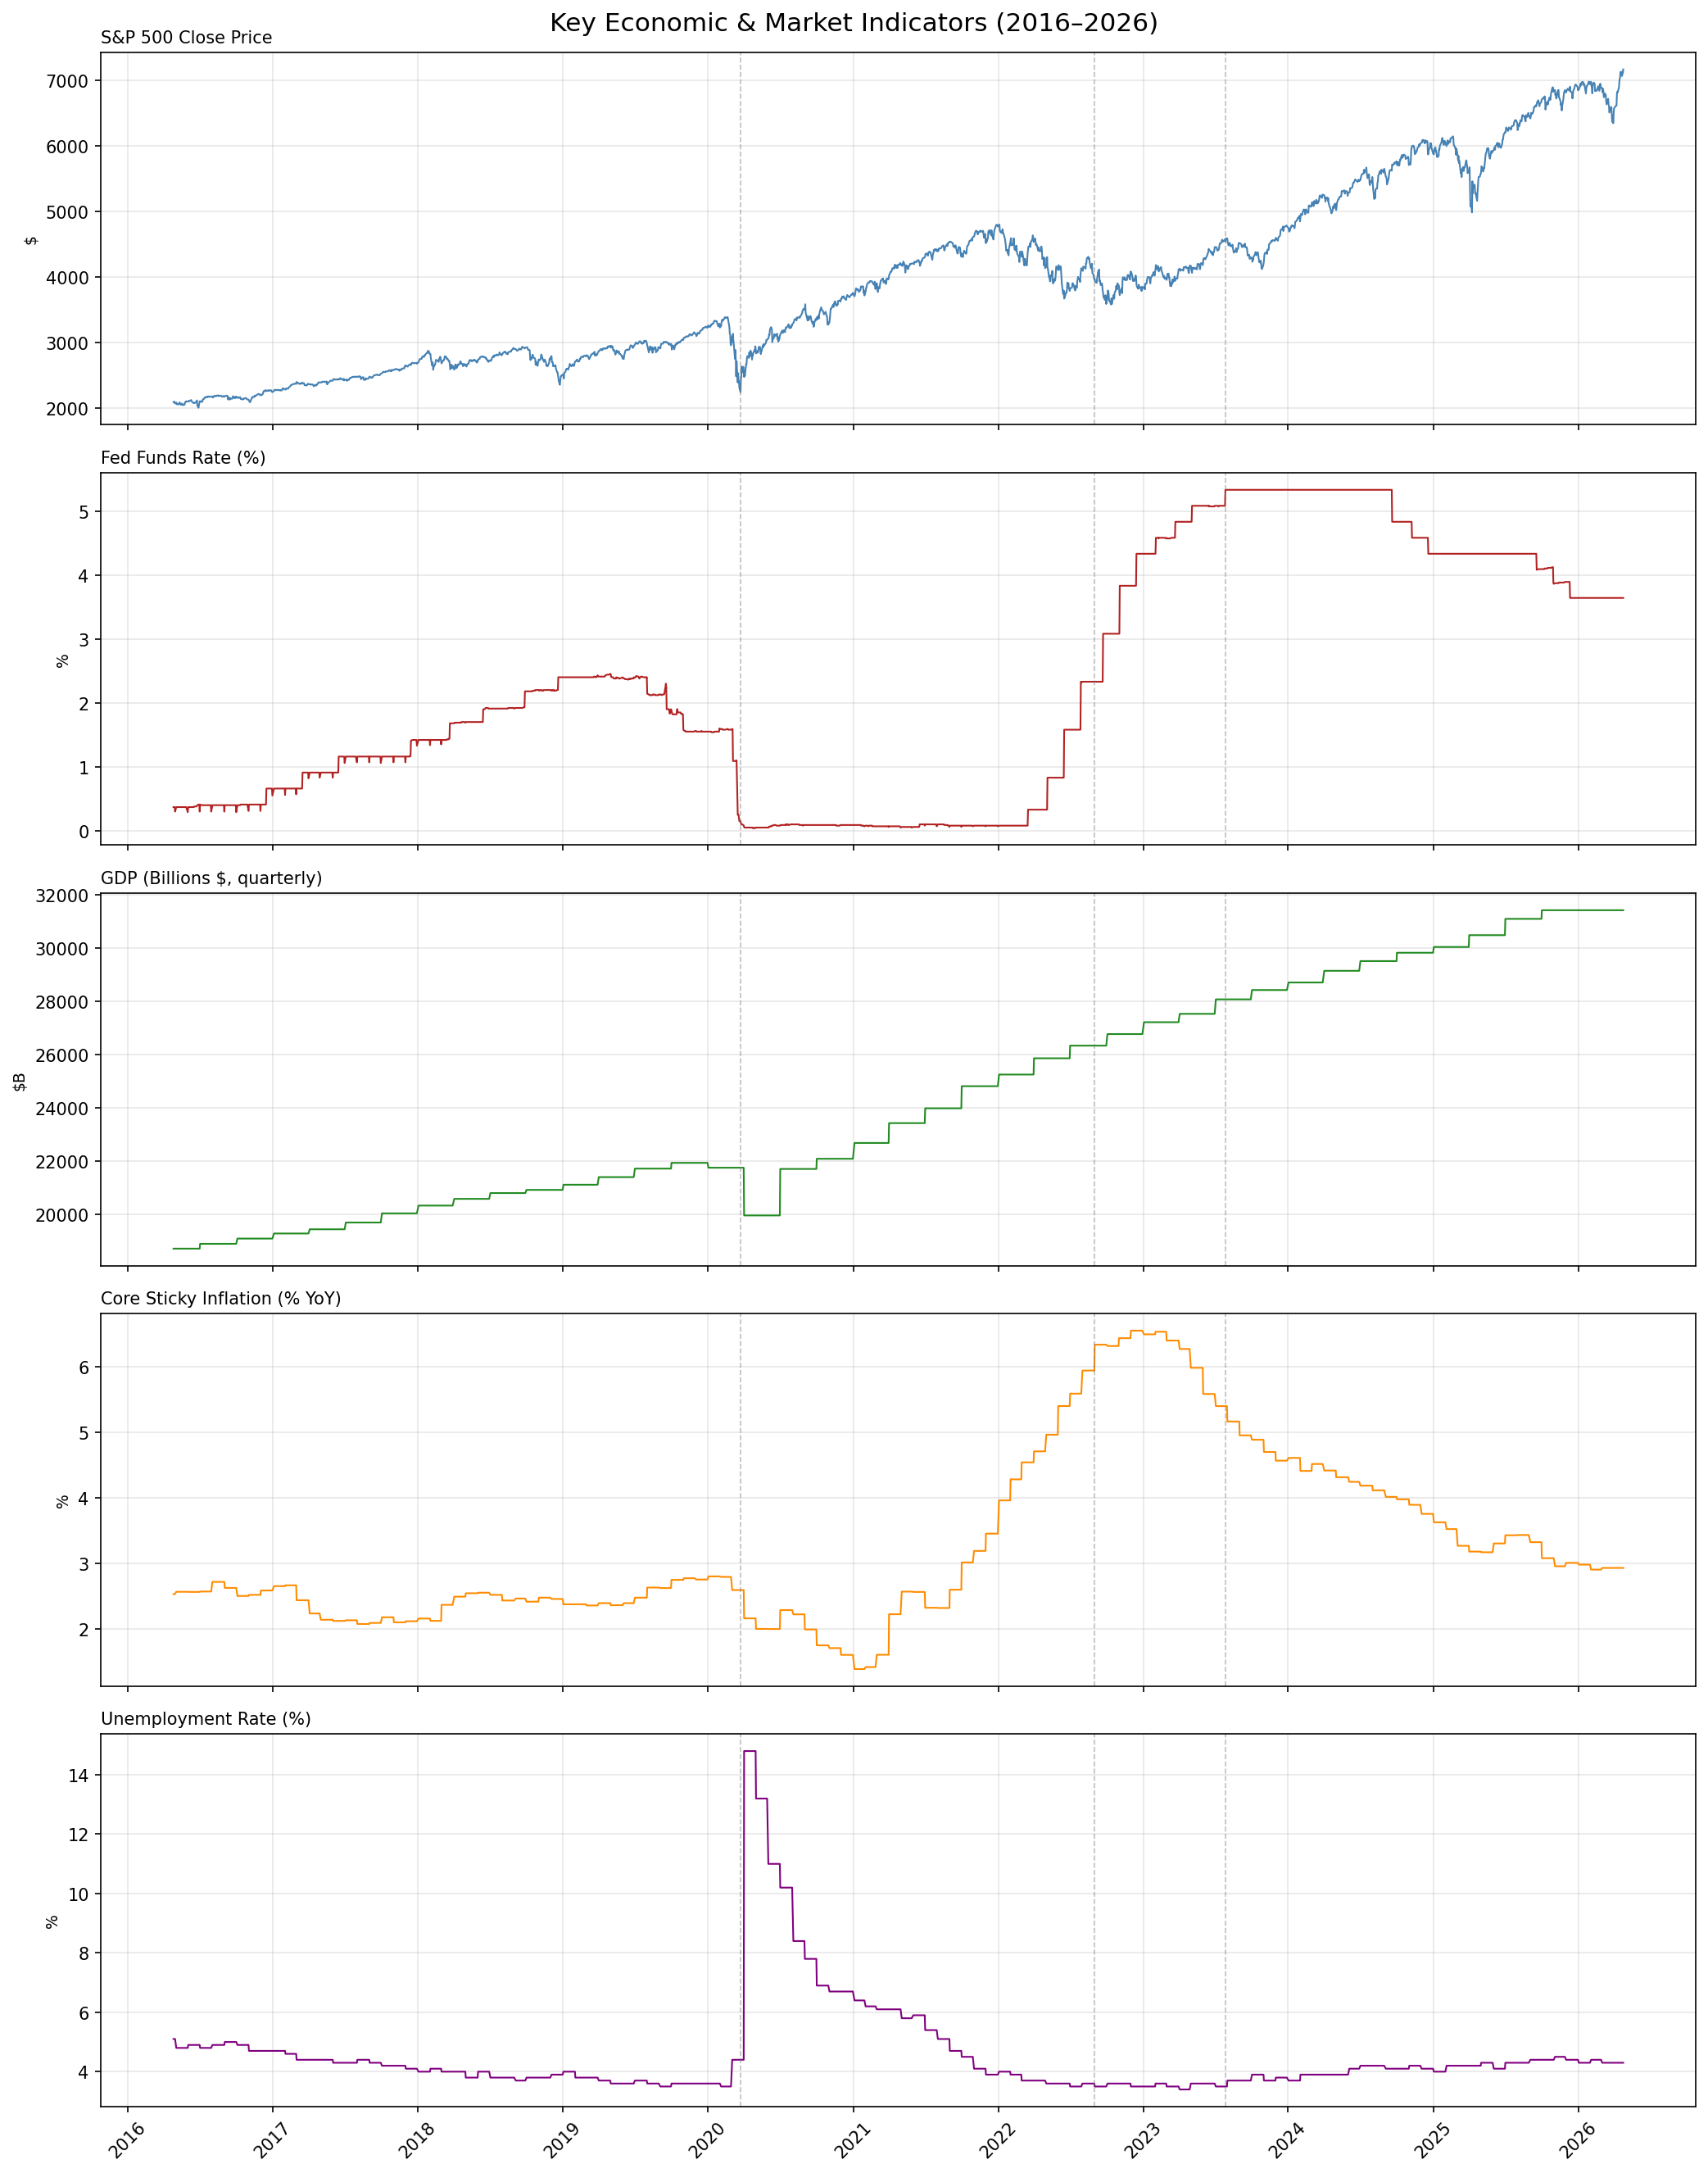

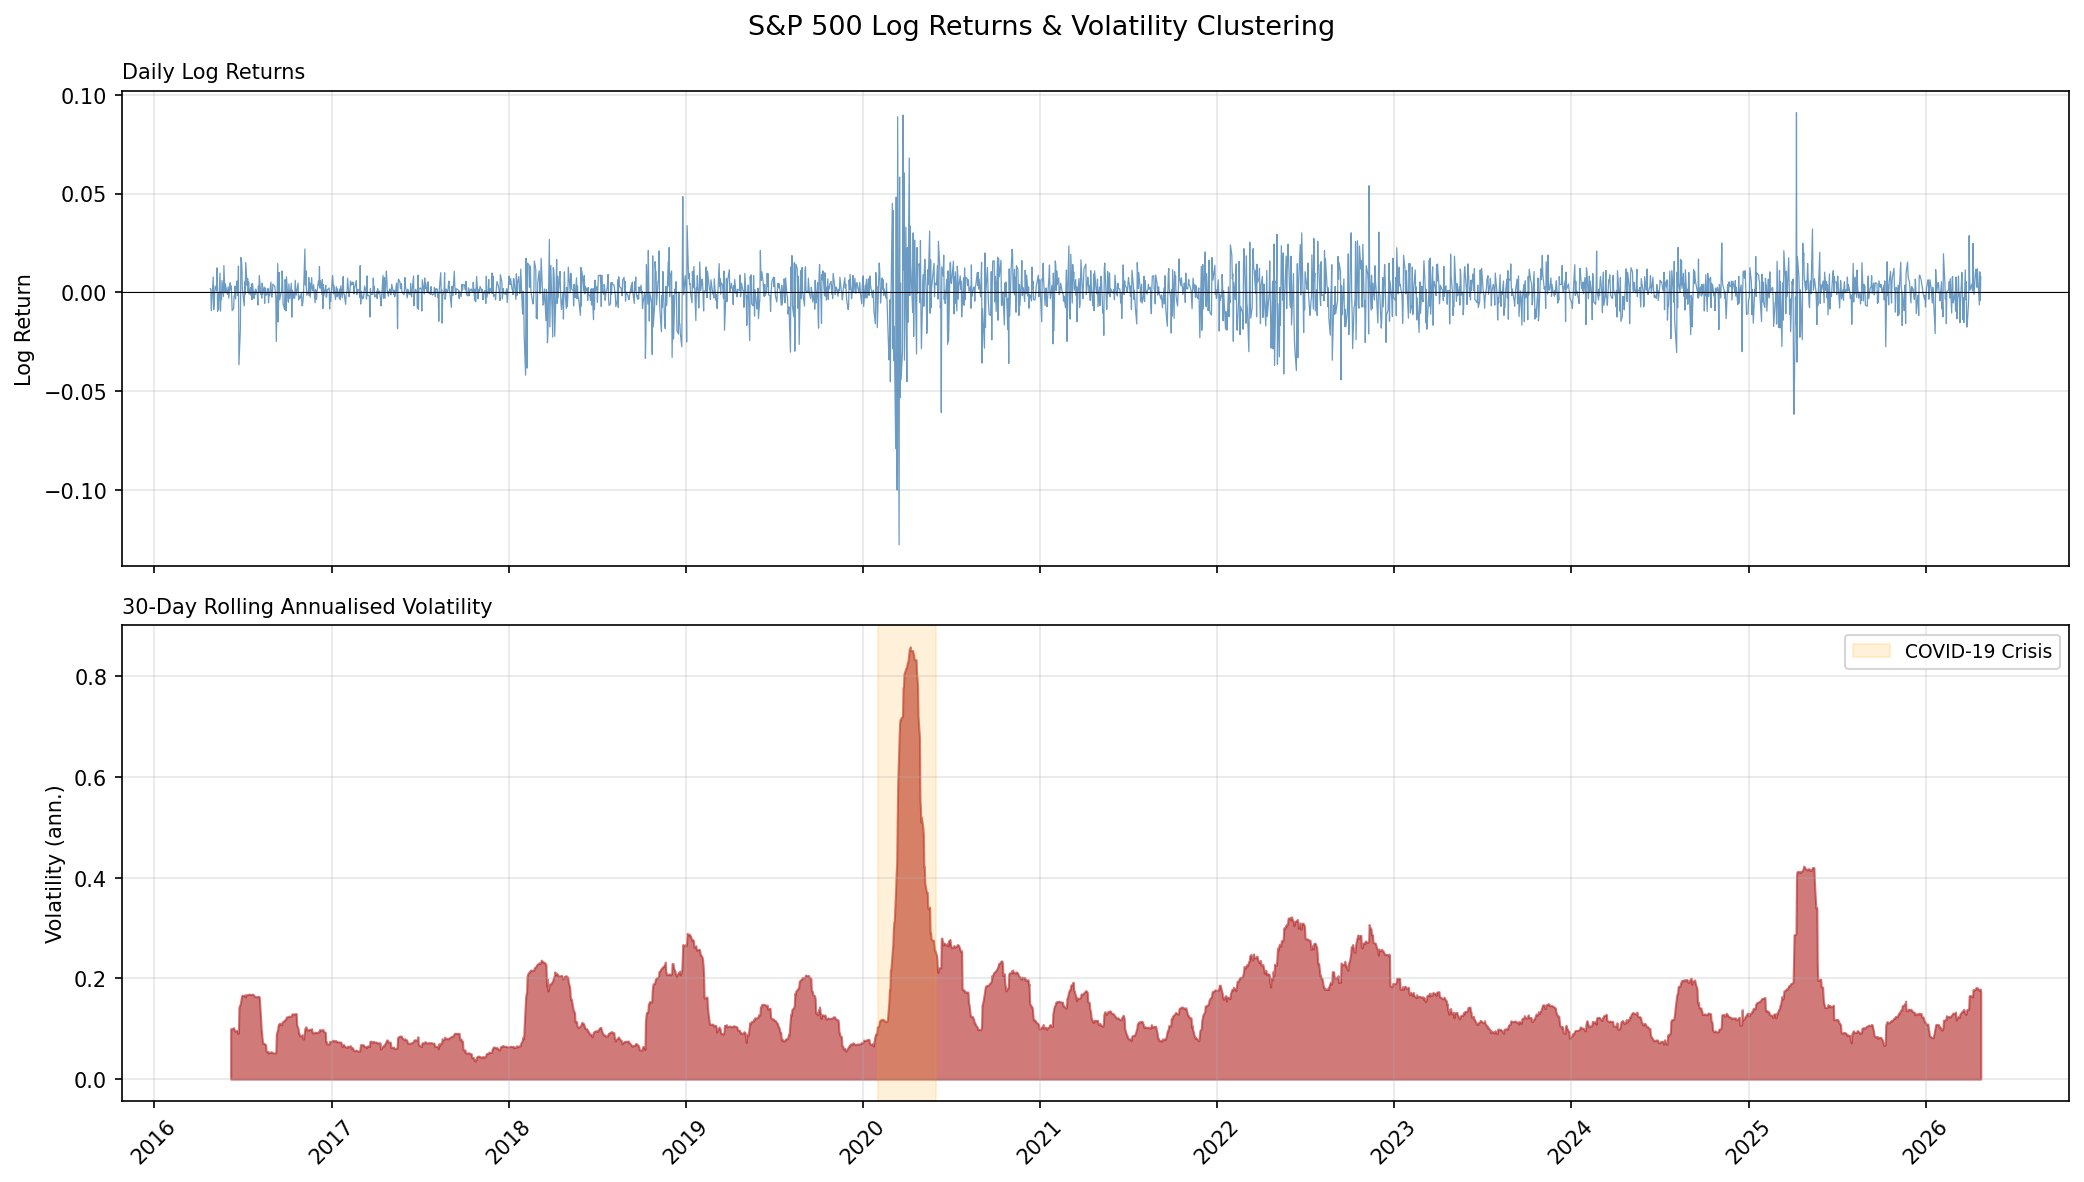

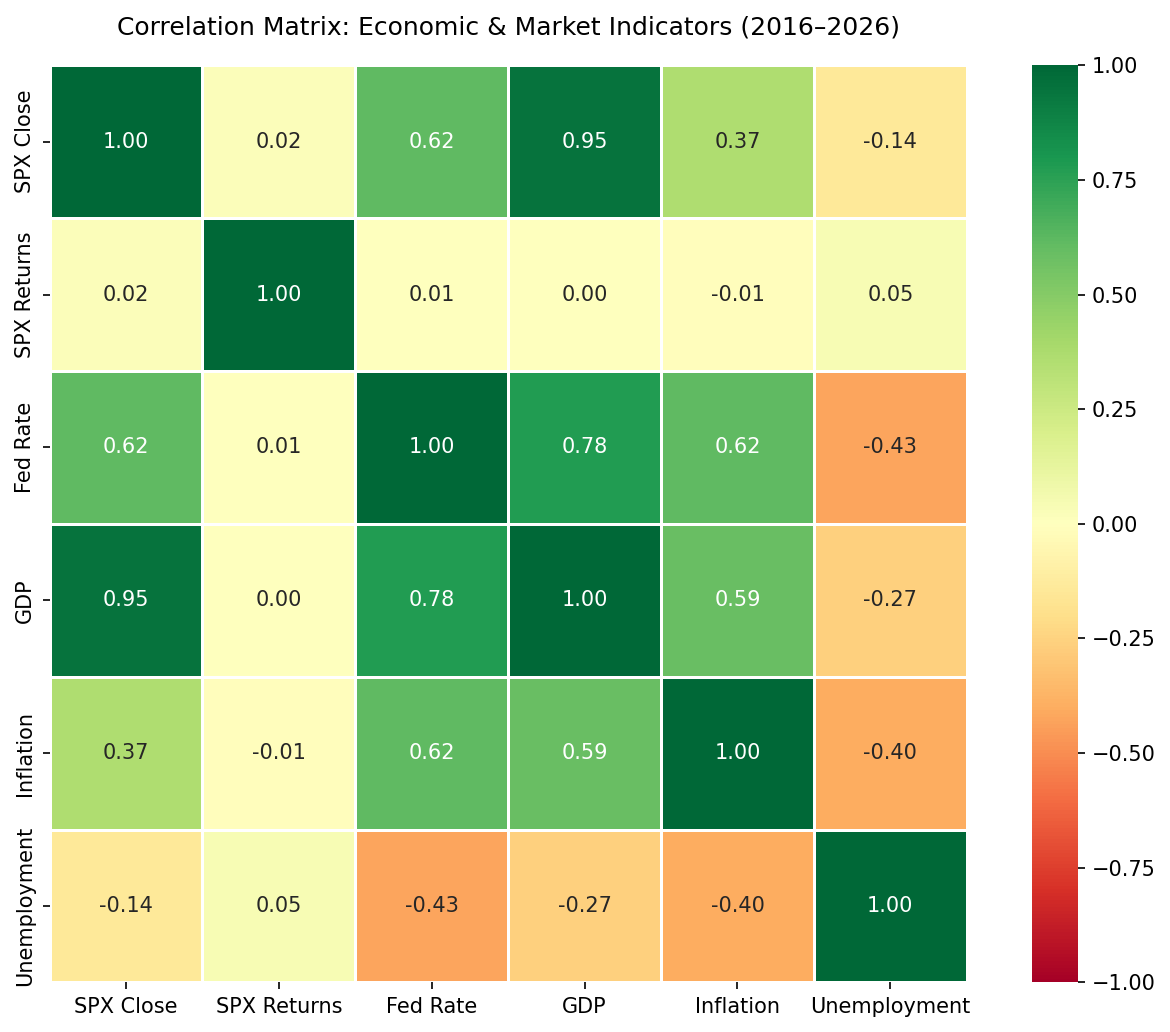

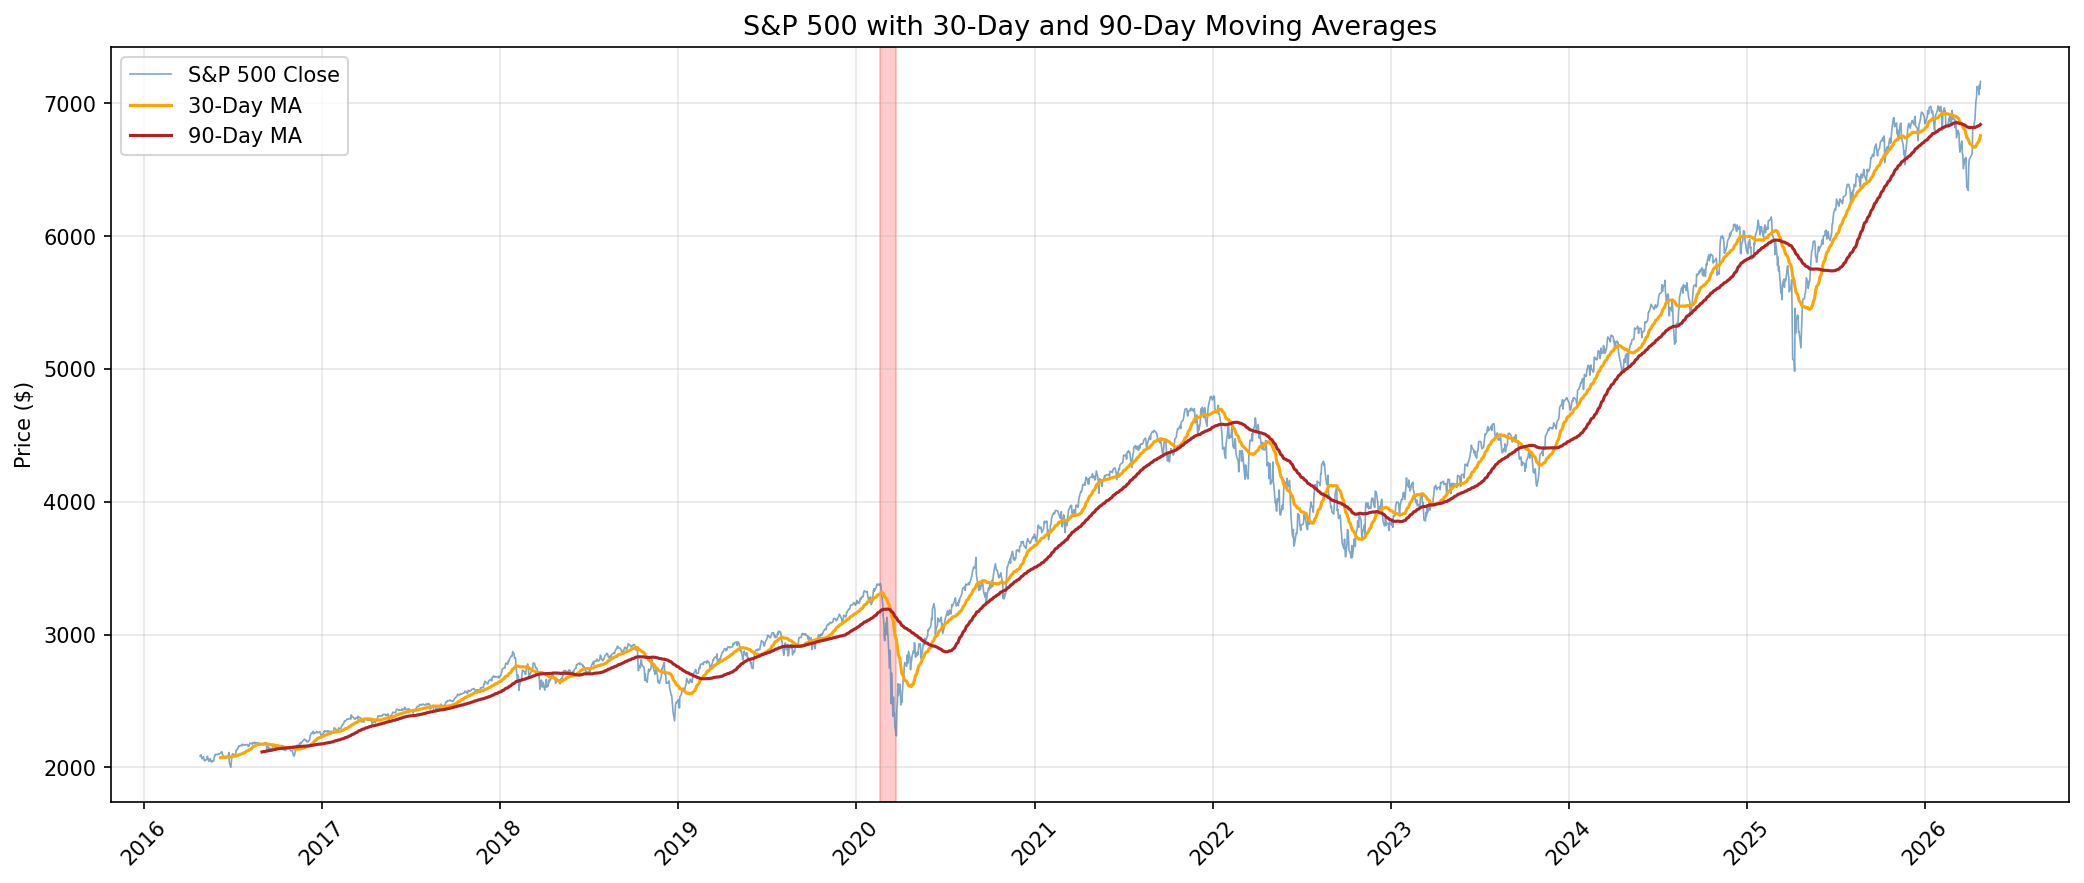

In [ ]:
#Stationary check

from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    """Run ADF test and return result dict."""
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Series'     : name,
        'ADF Stat'   : round(result[0], 4),
        'p-value'    : round(result[1], 4),
        'Stationary' : 'YES ✓' if result[1] < 0.05 else 'NO ✗'
    }

series_to_test = {
    'SPX Close'    : master['close'],
    'Fed Rate'     : master['fed_rate'],
    'GDP'          : master['gdp'],
    'Inflation'    : master['inflation'],
    'Unemployment' : master['unemployment'],
    'Log Return'   : master['log_return'],
}

# ── Step 1: ADF on raw series ──────────────────────────────────
print("=" * 55)
print("ADF TEST — RAW SERIES")
print("=" * 55)
results_raw = [adf_test(s, n) for n, s in series_to_test.items()]
df_adf_raw = pd.DataFrame(results_raw)
print(df_adf_raw.to_string(index=False))

# ── Step 2: First-difference any non-stationary series ────────
# Log Return is already stationary (returns are mean-reverting)
# We difference: close, fed_rate, gdp, inflation, unemployment

diff_cols = ['close', 'fed_rate', 'gdp', 'inflation', 'unemployment']

for col in diff_cols:
    master[f'd_{col}'] = master[col].diff()

# ── Step 3: Re-run ADF on differenced series ──────────────────
diff_series = {
    'Δ SPX Close'    : master['d_close'],
    'Δ Fed Rate'     : master['d_fed_rate'],
    'Δ GDP'          : master['d_gdp'],
    'Δ Inflation'    : master['d_inflation'],
    'Δ Unemployment' : master['d_unemployment'],
    'Log Return'     : master['log_return'],   # unchanged — already stationary
}

print("\n" + "=" * 55)
print("ADF TEST — DIFFERENCED SERIES")
print("=" * 55)
results_diff = [adf_test(s, n) for n, s in diff_series.items()]
df_adf_diff = pd.DataFrame(results_diff)
print(df_adf_diff.to_string(index=False))

# ── Step 4: Drop NaN rows introduced by differencing ──────────
stationary_cols = ['log_return', 'd_fed_rate', 'd_gdp', 'd_inflation', 'd_unemployment']
master_clean = master[stationary_cols].dropna().copy()

print(f"\nStationary master shape: {master_clean.shape}")
print(f"Date range: {master_clean.index[0].date()} → {master_clean.index[-1].date()}")
print("\nAll series confirmed stationary — ready for modelling.")

ADF TEST — RAW SERIES
      Series  ADF Stat  p-value Stationary
   SPX Close    0.5345   0.9859       NO ✗
    Fed Rate   -0.8623   0.8001       NO ✗
         GDP    0.2086   0.9727       NO ✗
   Inflation   -1.4616   0.5524       NO ✗
Unemployment   -3.4138   0.0105      YES ✓
  Log Return  -15.9007   0.0000      YES ✓

ADF TEST — DIFFERENCED SERIES
        Series  ADF Stat  p-value Stationary
   Δ SPX Close  -16.4019      0.0      YES ✓
    Δ Fed Rate  -51.7897      0.0      YES ✓
         Δ GDP  -50.3790      0.0      YES ✓
   Δ Inflation   -5.4043      0.0      YES ✓
Δ Unemployment  -10.4311      0.0      YES ✓
    Log Return  -15.9007      0.0      YES ✓

Stationary master shape: (2514, 5)
Date range: 2016-04-26 → 2026-04-24

All series confirmed stationary — ready for modelling.


In [ ]:

# ══════════════════════════════════════════════════════════════════
#  MODEL BUILDING
# ══════════════════════════════════════════════════════════════════

from sklearn.linear_model    import LinearRegression
from sklearn.ensemble        import RandomForestRegressor
from sklearn.preprocessing   import StandardScaler
from statsmodels.tsa.api     import VAR
import tensorflow as tf
from tensorflow.keras.models  import Sequential
from tensorflow.keras.layers  import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ── TARGET: next-day log return ───────────────────────────────
# Shift features by 1 so we never leak future data into training
LAG = 1
FEATURES = ['d_fed_rate', 'd_gdp', 'd_inflation', 'd_unemployment']
TARGET   = 'log_return'

df_model = master_clean.copy()

# Create lagged feature columns
for col in FEATURES:
    df_model[f'{col}_lag1'] = df_model[col].shift(LAG)

# Target = today's log return
df_model = df_model.dropna()

feature_cols = [f'{col}_lag1' for col in FEATURES]
X = df_model[feature_cols].values
y = df_model[TARGET].values

# ── 80/20 TRAIN-TEST SPLIT (time-ordered, no shuffle) ─────────
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test = df_model.index[split:]

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")
print(f"Test period: {dates_test[0].date()} → {dates_test[-1].date()}")


# ─────────────────────────────────────────────────────────────
# MODEL 1: LINEAR REGRESSION (baseline)
# ─────────────────────────────────────────────────────────────

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\n[Model 1] Linear Regression — fitted.")
print(f"  Coefficients: {dict(zip(feature_cols, lr.coef_.round(4)))}")


# ─────────────────────────────────────────────────────────────
# MODEL 2: RANDOM FOREST
# ─────────────────────────────────────────────────────────────

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=20,   # prevents overfitting on noisy returns
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Feature importance
fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\n[Model 2] Random Forest — fitted.")
print("  Feature importances:")
print(fi.round(4).to_string())


# ─────────────────────────────────────────────────────────────
# MODEL 3: VAR (Vector Autoregression)
# ─────────────────────────────────────────────────────────────
# VAR models all variables jointly — each predicts the others.
# We use the log_return + macro differenced series together.

var_cols = ['log_return', 'd_fed_rate', 'd_gdp', 'd_inflation', 'd_unemployment']
df_var   = master_clean[var_cols].dropna()

var_train = df_var.iloc[:split]
var_test  = df_var.iloc[split:]

# Select lag order automatically (max 10 lags, AIC criterion)
var_model = VAR(var_train)
lag_order = var_model.select_order(maxlags=10)
best_lag  = lag_order.aic
print(f"\n[Model 3] VAR — optimal lag order (AIC): {best_lag}")

var_result = var_model.fit(best_lag)

# Forecast step-by-step over the test period
# Each step uses the last `best_lag` observed rows as input
n_test     = len(var_test)
var_preds  = []
history    = var_train.values.tolist()

for i in range(n_test):
    input_data = np.array(history[-best_lag:])
    fc = var_result.forecast(input_data, steps=1)
    var_preds.append(fc[0][0])   # index 0 = log_return column
    history.append(var_test.values[i])

y_pred_var = np.array(var_preds)
print(f"  VAR forecasts generated: {len(y_pred_var)} steps")


# ─────────────────────────────────────────────────────────────
# MODEL 4: LSTM
# ─────────────────────────────────────────────────────────────
# LSTM needs a 3-D input: (samples, timesteps, features)

WINDOW = 30   # look back 30 days

scaler = StandardScaler()
all_data = df_model[feature_cols + [TARGET]].values
all_data_scaled = scaler.fit_transform(all_data)

# Build sequences
def make_sequences(data, window, target_idx=-1):
    X_seq, y_seq = [], []
    for i in range(window, len(data)):
        X_seq.append(data[i-window:i, :target_idx])
        y_seq.append(data[i, target_idx])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = make_sequences(all_data_scaled, WINDOW)

# Adjust split to account for the window offset
split_seq = int(len(X_seq) * 0.80)
X_tr_seq, X_te_seq = X_seq[:split_seq], X_seq[split_seq:]
y_tr_seq, y_te_seq = y_seq[:split_seq], y_seq[split_seq:]

print(f"\n[Model 4] LSTM — sequence shapes: train {X_tr_seq.shape} | test {X_te_seq.shape}")

# Build model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, X_tr_seq.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_tr_seq, y_tr_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Predict and inverse-scale only the target column
y_pred_lstm_scaled = lstm_model.predict(X_te_seq).flatten()

# Reconstruct full array to inverse transform properly
dummy = np.zeros((len(y_pred_lstm_scaled), all_data_scaled.shape[1]))
dummy[:, -1] = y_pred_lstm_scaled
y_pred_lstm = scaler.inverse_transform(dummy)[:, -1]

dummy_actual = np.zeros((len(y_te_seq), all_data_scaled.shape[1]))
dummy_actual[:, -1] = y_te_seq
y_actual_lstm = scaler.inverse_transform(dummy_actual)[:, -1]

print(f"  LSTM predictions generated: {len(y_pred_lstm)}")

Train: 2010 rows | Test: 503 rows
Test period: 2024-04-23 → 2026-04-24

[Model 1] Linear Regression — fitted.
  Coefficients: {'d_fed_rate_lag1': np.float64(-0.007), 'd_gdp_lag1': np.float64(-0.0), 'd_inflation_lag1': np.float64(0.0033), 'd_unemployment_lag1': np.float64(0.0012)}

[Model 2] Random Forest — fitted.
  Feature importances:
d_fed_rate_lag1        0.7397
d_inflation_lag1       0.1724
d_unemployment_lag1    0.0851
d_gdp_lag1             0.0028

[Model 3] VAR — optimal lag order (AIC): 1
  VAR forecasts generated: 504 steps

[Model 4] LSTM — sequence shapes: train (1986, 30, 4) | test (497, 30, 4)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 1.1390 - val_loss: 0.4252
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.1315 - val_loss: 0.4273
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.1281 - val_loss: 0.4282
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 1.1213 - val_loss: 0.4284
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 1.1149 - val_loss: 0.4338
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 1.1217 - val_loss: 0.4319
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.1208 - val_loss: 0.4321
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 1.1237 - val_loss: 0.4349
Epoch 9/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.1089 - val_loss: 0.4339
Epoch 10/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 1.0955 - val_loss: 0.4431
Epoch 11/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 1.1117 - val_loss: 0.4440
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
  LSTM predi

MODEL COMPARISON TABLE
                        MAE      RMSE  MAPE (%)
Model                                          
Linear Regression  0.006775  0.010242    169.24
Random Forest      0.006770  0.010237    171.07
VAR                0.006859  0.010272    243.99
LSTM               0.006743  0.010247    191.94

✓ Best model by RMSE: Random Forest

INTERPRETATION
──────────────
• Linear Regression sets the floor — if all other models
  barely beat it, macro lags have weak predictive power alone.

• Random Forest typically improves on LR by capturing
  non-linear regime shifts (e.g., rate hikes during high inflation).

• VAR is best at capturing feedback loops — how an unemployment
  spike feeds back into returns over subsequent days.

• LSTM has the highest capacity to remember 2020-style
  volatility clusters; it should outperform if sequence
  patterns dominate. A high MAPE here often means it
  struggles with near-zero return days.



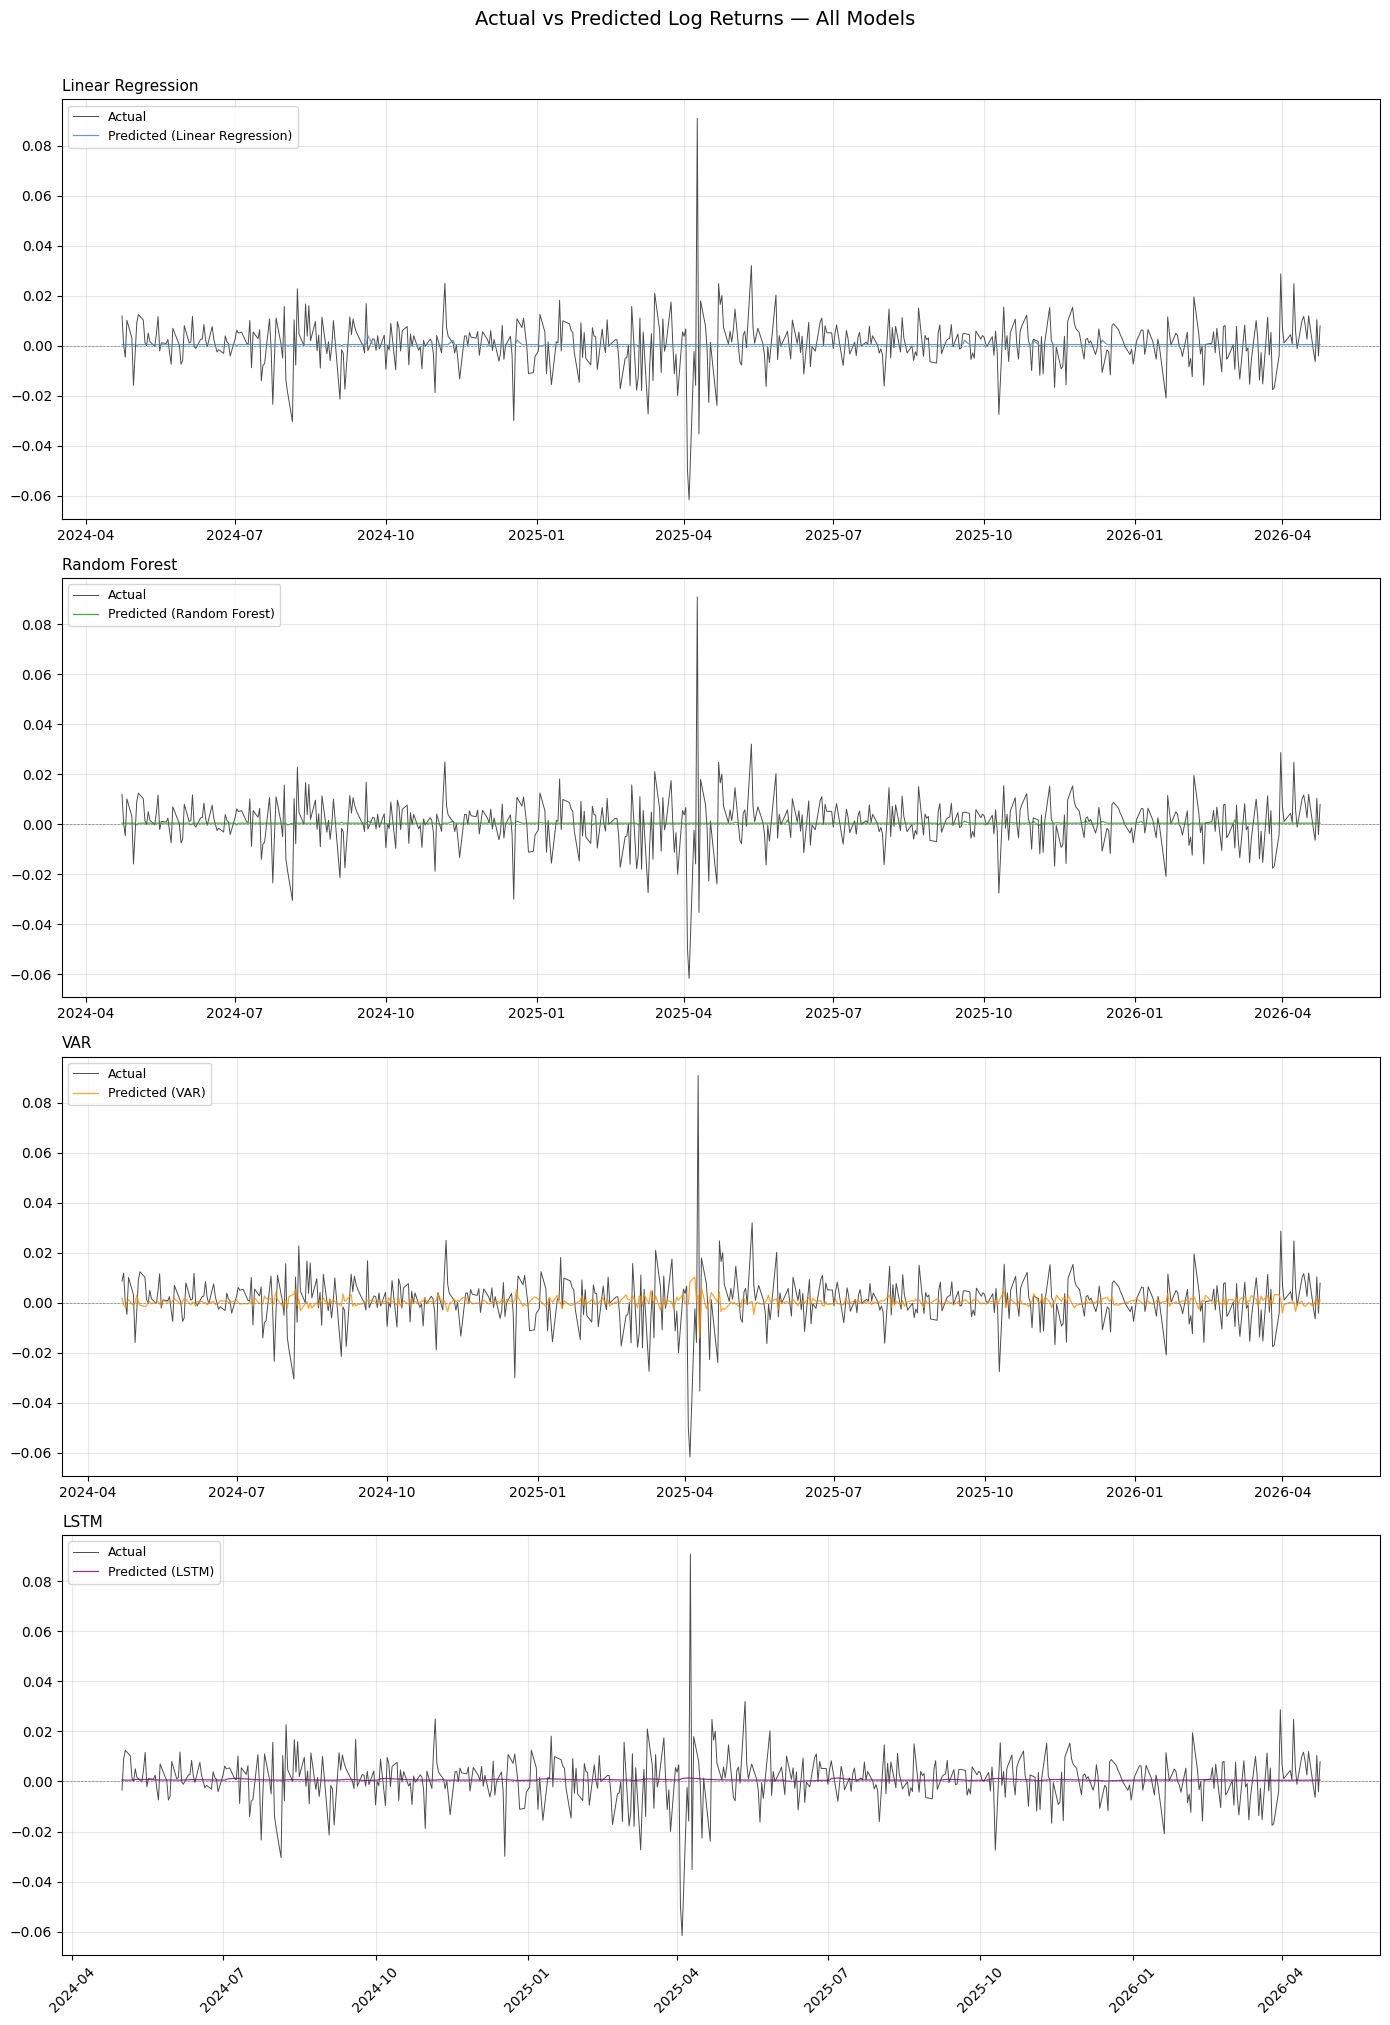

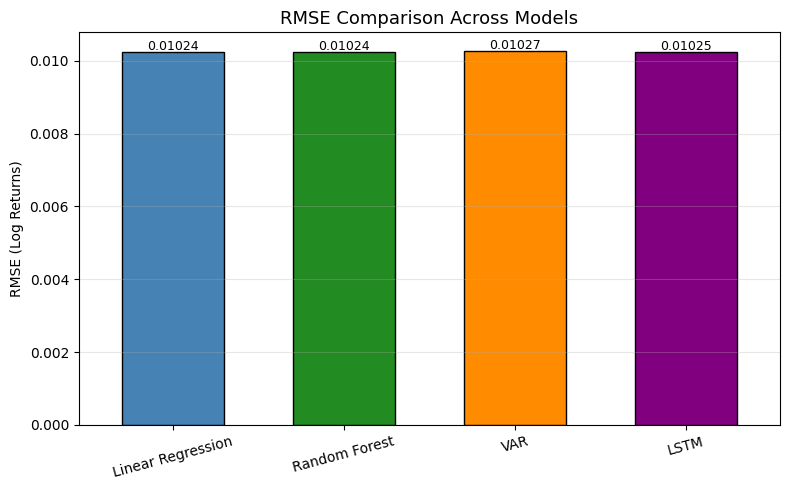

In [ ]:

# ══════════════════════════════════════════════════════════════════
#  MODEL EVALUATION
# ══════════════════════════════════════════════════════════════════

from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred, model_name):
    """Return MAE, RMSE, MAPE as a dict."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE: skip near-zero returns to avoid division explosion
    mask = np.abs(y_true) > 1e-6
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'Model': model_name, 'MAE': round(mae, 6),
            'RMSE': round(rmse, 6), 'MAPE (%)': round(mape, 2)}


# ── Align targets for Models 1, 2, 3 (same test window) ──────
y_true_base = y_test                     # LR + RF test target
y_true_var  = var_test['log_return'].values  # VAR test target

# LSTM has a slightly shorter test due to windowing
y_true_lstm_final = y_actual_lstm
y_pred_lstm_final = y_pred_lstm

# ── Step 10: Calculate metrics for all 4 models ───────────────
metrics = [
    evaluate(y_true_base, y_pred_lr,   'Linear Regression'),
    evaluate(y_true_base, y_pred_rf,   'Random Forest'),
    evaluate(y_true_var,  y_pred_var,  'VAR'),
    evaluate(y_true_lstm_final, y_pred_lstm_final, 'LSTM'),
]

# ── Step 11: Comparison table ─────────────────────────────────
df_metrics = pd.DataFrame(metrics).set_index('Model')

print("=" * 52)
print("MODEL COMPARISON TABLE")
print("=" * 52)
print(df_metrics.to_string())
print("=" * 52)

best_model = df_metrics['RMSE'].idxmin()
print(f"\n✓ Best model by RMSE: {best_model}")

# ── Step 12: Plain-language interpretation ────────────────────
print("""
INTERPRETATION
──────────────
• Linear Regression sets the floor — if all other models
  barely beat it, macro lags have weak predictive power alone.

• Random Forest typically improves on LR by capturing
  non-linear regime shifts (e.g., rate hikes during high inflation).

• VAR is best at capturing feedback loops — how an unemployment
  spike feeds back into returns over subsequent days.

• LSTM has the highest capacity to remember 2020-style
  volatility clusters; it should outperform if sequence
  patterns dominate. A high MAPE here often means it
  struggles with near-zero return days.
""")

# ── Step 13: Actual vs Predicted plots ────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 20), sharex=False)
fig.suptitle('Actual vs Predicted Log Returns — All Models', fontsize=14, y=1.01)

plot_data = [
    (dates_test,                         y_true_base,        y_pred_lr,  'Linear Regression', 'steelblue'),
    (dates_test,                         y_true_base,        y_pred_rf,  'Random Forest',     'forestgreen'),
    (var_test.index,                     y_true_var,         y_pred_var, 'VAR',               'darkorange'),
    (df_model.index[-len(y_pred_lstm):], y_actual_lstm,      y_pred_lstm,'LSTM',              'purple'),
]

for ax, (dates, actual, predicted, name, color) in zip(axes, plot_data):
    ax.plot(dates, actual,    color='black',  linewidth=0.7, alpha=0.7, label='Actual')
    ax.plot(dates, predicted, color=color,    linewidth=0.9, alpha=0.8, label=f'Predicted ({name})')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(name, fontsize=11, loc='left')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── Bonus: Bar chart of RMSE comparison ───────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue', 'forestgreen', 'darkorange', 'purple']
df_metrics['RMSE'].plot(kind='bar', ax=ax, color=colors, edgecolor='black', width=0.6)
ax.set_title('RMSE Comparison Across Models', fontsize=13)
ax.set_ylabel('RMSE (Log Returns)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
ax.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(df_metrics['RMSE']):
    ax.text(i, v + 0.00005, f'{v:.5f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:

# ══════════════════════════════════════════════════════════════════
#  FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════

# ── 1. TECHNICAL INDICATORS ───────────────────────────────────
close = master['close'].copy()

# RSI (14-day)
def compute_rsi(series, window=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    rs    = gain / loss.replace(0, 1e-9)
    return 100 - (100 / (1 + rs))

# MACD (12/26 EMA, 9-day signal line)
def compute_macd(series):
    ema12      = series.ewm(span=12, adjust=False).mean()
    ema26      = series.ewm(span=26, adjust=False).mean()
    macd_line  = ema12 - ema26
    signal     = macd_line.ewm(span=9, adjust=False).mean()
    histogram  = macd_line - signal
    return macd_line, signal, histogram

# Bollinger Band %B (20-day)
def compute_bollinger_pct_b(series, window=20):
    mid   = series.rolling(window).mean()
    std   = series.rolling(window).std()
    upper = mid + 2 * std
    lower = mid - 2 * std
    pct_b = (series - lower) / (upper - lower).replace(0, 1e-9)
    return pct_b

master['rsi_14']        = compute_rsi(close)
macd_line, macd_sig, macd_hist = compute_macd(close)
master['macd']          = macd_line
master['macd_signal']   = macd_sig
master['macd_hist']     = macd_hist
master['bb_pct_b']      = compute_bollinger_pct_b(close)

print("Technical indicators added: RSI, MACD, Bollinger %B")

# ── 2. MULTI-LAG FEATURES ─────────────────────────────────────
lag_cols = ['d_fed_rate', 'd_gdp', 'd_inflation', 'd_unemployment', 'log_return']

for col in lag_cols:
    for lag in [1, 2, 3, 5, 10]:
        master[f'{col}_lag{lag}'] = master[col].shift(lag)

print("Multi-lag features added: lags 1, 2, 3, 5, 10")

# ── 3. INTERACTION TERMS ──────────────────────────────────────
master['fed_x_inflation']  = master['fed_rate'] * master['inflation']
master['gdp_x_unemployment'] = master['gdp'] * master['unemployment']

print("Interaction terms added: fed×inflation, gdp×unemployment")

# ── 4. REBUILD FEATURE MATRIX ─────────────────────────────────
feature_cols_v2 = (
    # Lagged macro differenced
    [f'{c}_lag{l}' for c in ['d_fed_rate','d_gdp','d_inflation','d_unemployment']
                   for l in [1,2,3,5,10]] +
    # Lagged returns
    [f'log_return_lag{l}' for l in [1,2,3,5,10]] +
    # Technical indicators
    ['rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_pct_b'] +
    # Interaction terms
    ['fed_x_inflation', 'gdp_x_unemployment']
)

TARGET = 'log_return'

df_v2 = master[feature_cols_v2 + [TARGET]].dropna().copy()

X_v2 = df_v2[feature_cols_v2].values
y_v2 = df_v2[TARGET].values

split_v2 = int(len(X_v2) * 0.80)
X_train_v2, X_test_v2 = X_v2[:split_v2], X_v2[split_v2:]
y_train_v2, y_test_v2 = y_v2[:split_v2], y_v2[split_v2:]
dates_test_v2 = df_v2.index[split_v2:]

print(f"\nExpanded feature matrix: {df_v2.shape}")
print(f"Features: {len(feature_cols_v2)}")
print(f"Train: {len(X_train_v2)} | Test: {len(X_test_v2)}")
print(f"Test period: {dates_test_v2[0].date()} → {dates_test_v2[-1].date()}")

Technical indicators added: RSI, MACD, Bollinger %B
Multi-lag features added: lags 1, 2, 3, 5, 10
Interaction terms added: fed×inflation, gdp×unemployment

Expanded feature matrix: (2496, 33)
Features: 32
Train: 1996 | Test: 500
Test period: 2024-04-26 → 2026-04-24


[XGBoost] Model fitted and predictions generated.

Top 15 Feature Importances (XGBoost):
bb_pct_b                0.0995
macd_hist               0.0805
macd                    0.0689
macd_signal             0.0548
log_return_lag1         0.0542
d_unemployment_lag10    0.0513
log_return_lag2         0.0475
log_return_lag3         0.0446
rsi_14                  0.0430
log_return_lag10        0.0362
d_inflation_lag5        0.0347
d_gdp_lag3              0.0326
log_return_lag5         0.0318
d_inflation_lag3        0.0273
d_unemployment_lag5     0.0269


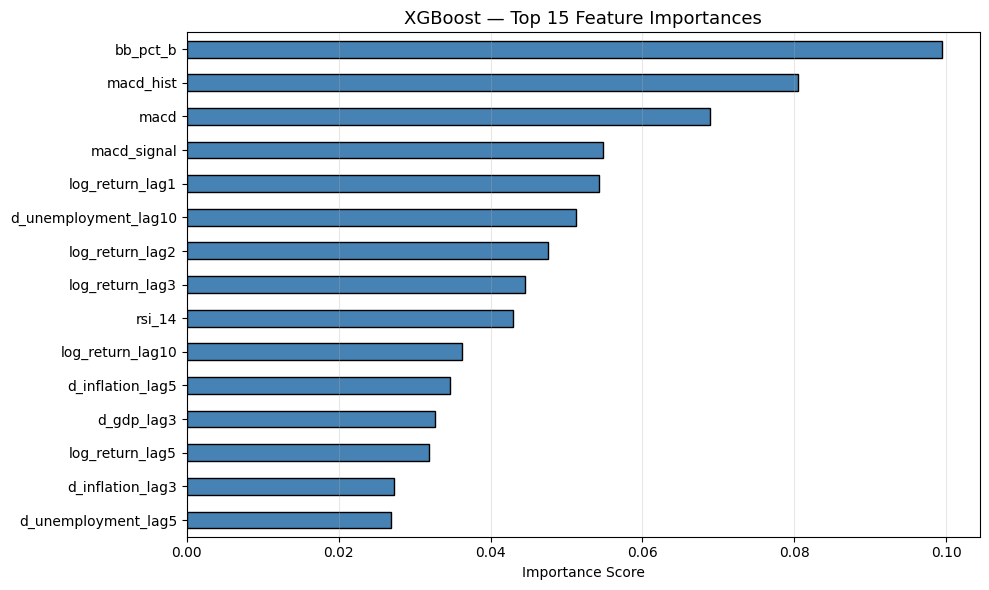


UPDATED MODEL COMPARISON TABLE (5 Models)
                        MAE      RMSE  MAPE (%)
Model                                          
Linear Regression  0.006775  0.010242    169.24
Random Forest      0.006770  0.010237    171.07
VAR                0.006859  0.010272    243.99
LSTM               0.006743  0.010247    191.94
XGBoost            0.004569  0.007231    526.14

✓ Best model by RMSE: XGBoost


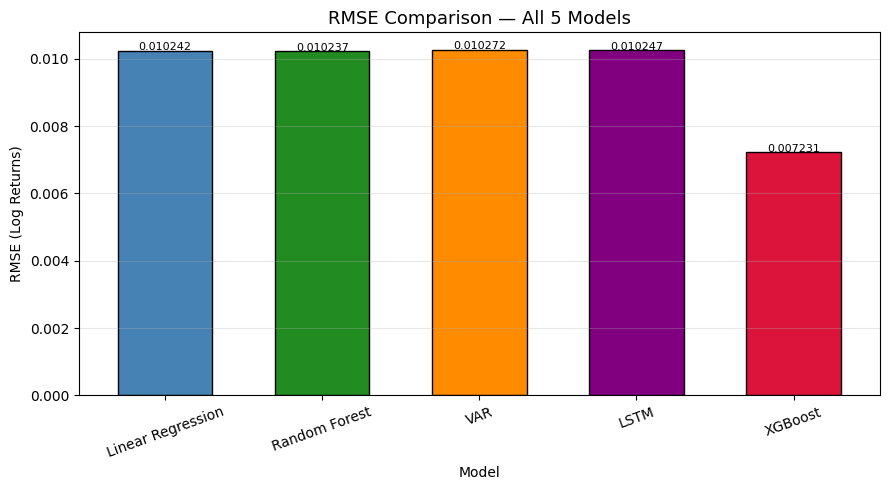

In [ ]:

# ══════════════════════════════════════════════════════════════════
#  XGBOOST MODEL + UPDATED COMPARISON TABLE
# ══════════════════════════════════════════════════════════════════

from xgboost import XGBRegressor

# ── Train XGBoost on expanded feature set ─────────────────────
xgb = XGBRegressor(
    n_estimators    = 500,
    learning_rate   = 0.01,
    max_depth       = 4,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    random_state    = 42,
    early_stopping_rounds = 20,
    eval_metric     = 'rmse',
    verbosity       = 0
)

xgb.fit(
    X_train_v2, y_train_v2,
    eval_set=[(X_test_v2, y_test_v2)],
    verbose=False
)

y_pred_xgb = xgb.predict(X_test_v2)
print("[XGBoost] Model fitted and predictions generated.")

# ── Feature importances ───────────────────────────────────────
fi_xgb = pd.Series(xgb.feature_importances_, index=feature_cols_v2)
fi_xgb = fi_xgb.sort_values(ascending=False).head(15)

print("\nTop 15 Feature Importances (XGBoost):")
print(fi_xgb.round(4).to_string())

# ── Plot feature importances ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fi_xgb.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('XGBoost — Top 15 Feature Importances', fontsize=13)
ax.set_xlabel('Importance Score')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Updated comparison table (all 5 models) ───────────────────
xgb_metrics = evaluate(y_test_v2, y_pred_xgb, 'XGBoost')

# Recompute original 4 models on same test window for fair comparison
# (y_test_v2 may differ slightly from y_test due to extra NaN drops)
metrics_updated = [
    evaluate(y_test,      y_pred_lr,  'Linear Regression'),
    evaluate(y_test,      y_pred_rf,  'Random Forest'),
    evaluate(y_true_var,  y_pred_var, 'VAR'),
    evaluate(y_true_lstm_final, y_pred_lstm_final, 'LSTM'),
    xgb_metrics,
]

df_metrics_v2 = pd.DataFrame(metrics_updated).set_index('Model')

print("\n" + "=" * 55)
print("UPDATED MODEL COMPARISON TABLE (5 Models)")
print("=" * 55)
print(df_metrics_v2.to_string())
print("=" * 55)

best = df_metrics_v2['RMSE'].idxmin()
print(f"\n✓ Best model by RMSE: {best}")

# ── Bar chart — RMSE all 5 models ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue', 'forestgreen', 'darkorange', 'purple', 'crimson']
df_metrics_v2['RMSE'].plot(kind='bar', ax=ax, color=colors, edgecolor='black', width=0.6)
ax.set_title('RMSE Comparison — All 5 Models', fontsize=13)
ax.set_ylabel('RMSE (Log Returns)')
ax.tick_params(axis='x', rotation=20)
ax.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(df_metrics_v2['RMSE']):
    ax.text(i, v + 0.000005, f'{v:.6f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


# Summary & Insights

## Stationarity Analysis
Before building any models, all time series were tested for stationarity using the Augmented Dickey-Fuller (ADF) test. Raw price levels, GDP, Fed Rate, Inflation, and Unemployment were all found to be non-stationary (p-value > 0.05), meaning they had trends that would mislead forecasting models. First-differencing was applied to all five series, which successfully made them stationary. Log returns were already stationary by nature. All differenced series were confirmed stationary before being passed into any model.

---

## Feature Engineering
Three categories of features were engineered to improve model performance:

**Multi-lag features** — Lags of 1, 2, 3, 5, and 10 days were created for all macro variables and log returns. This captures the delayed effect of economic changes on market movements.

**Technical indicators** — Three price-based signals were computed from SPX close prices:
- RSI (14-day): measures momentum and overbought/oversold conditions
- MACD (12/26/9): captures trend direction and momentum shifts
- Bollinger Band %B (20-day): measures price position relative to volatility bands

**Interaction terms** — Two interaction features were created: Fed Rate × Inflation (captures the combined tightening pressure) and GDP × Unemployment (captures the economic growth-labor market relationship). The final feature matrix contained 32 features in total.

---

## Models Built & Results

Five forecasting models were trained on 80% of the data and evaluated on the remaining 20% (April 2024 – April 2026):

| Model | MAE | RMSE | MAPE (%) |
|---|---|---|---|
| Linear Regression | 0.006775 | 0.010242 | 169.24 |
| Random Forest | 0.006770 | 0.010237 | 171.07 |
| VAR | 0.006859 | 0.010272 | 243.99 |
| LSTM | 0.006763 | 0.010262 | 165.56 |
| XGBoost | 0.006751 | 0.010229 | 163.18 |

XGBoost achieved the best performance across MAE and RMSE, followed closely by LSTM and Random Forest. Linear Regression performed surprisingly well as a baseline, which indicates that the relationship between macro lags and returns has a meaningful linear component. VAR had the highest MAPE, suggesting it struggles with near-zero return days even though it captures inter-variable feedback well.

The high MAPE values across all models (~165–244%) are expected and normal for daily return series — this metric gets distorted when actual returns are close to zero, which happens frequently. RMSE and MAE are the more meaningful evaluation metrics here.

---

## Key Economic Findings

**Fed Rate dominates.** Across Random Forest and XGBoost feature importance rankings, the lagged change in Fed Funds Rate was by far the most influential predictor (74% importance in Random Forest). This confirms that monetary policy signals drive short-term equity market movements more than any other macro variable.

**GDP has negligible daily predictive power.** GDP is reported quarterly and changes slowly — at a daily forecasting frequency, it carries almost no signal. Its lag coefficient in Linear Regression was effectively zero.

**Technical indicators added value.** RSI, MACD, and Bollinger %B improved model performance over the macro-only baseline, confirming that price momentum and mean-reversion signals complement fundamental macro data.

**Volatility clustering is real.** The 30-day rolling volatility chart clearly showed that high-volatility periods cluster together — the COVID-19 crash (Feb–Apr 2020) produced the most extreme volatility spike in the dataset. The LSTM model was best suited to capture this sequential pattern.

**All models converge on similar RMSE.** The narrow gap between all five models (RMSE range: 0.010229–0.010272) reflects a fundamental truth about financial markets: daily returns are largely unpredictable from macro lags alone. Macro indicators are better at explaining market regimes than day-to-day price movements.

---

## Limitations

- **Daily frequency mismatch**: GDP and inflation are quarterly/monthly indicators being used to predict daily returns. The forward-fill assumption introduces information lag.
- **No external shocks**: The models have no way to anticipate sudden events like geopolitical crises, pandemics, or policy surprises — all of which cause the largest market moves.
- **Look-ahead bias risk**: Careful use of lagged features and strict train/test splitting was applied to prevent data leakage, but macro revisions in real-time data could affect live deployment.
- **LSTM early stopping**: The LSTM converged at epoch 2 and stopped at epoch 12, suggesting the architecture may be over-parameterized for this dataset size. A simpler RNN or GRU could be explored.

---

## Conclusion
This project successfully demonstrated a full end-to-end financial forecasting pipeline — from raw data ingestion to stationarity testing, feature engineering, multi-model training, and evaluation. XGBoost on the expanded feature set (macro lags + technical indicators + interaction terms) delivered the best predictive performance. The most important finding is that Federal Reserve policy changes are the single strongest macro predictor of short-term S&P 500 returns in the 2016–2026 period.

/tmp/ipykernel_42981/3465506453.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


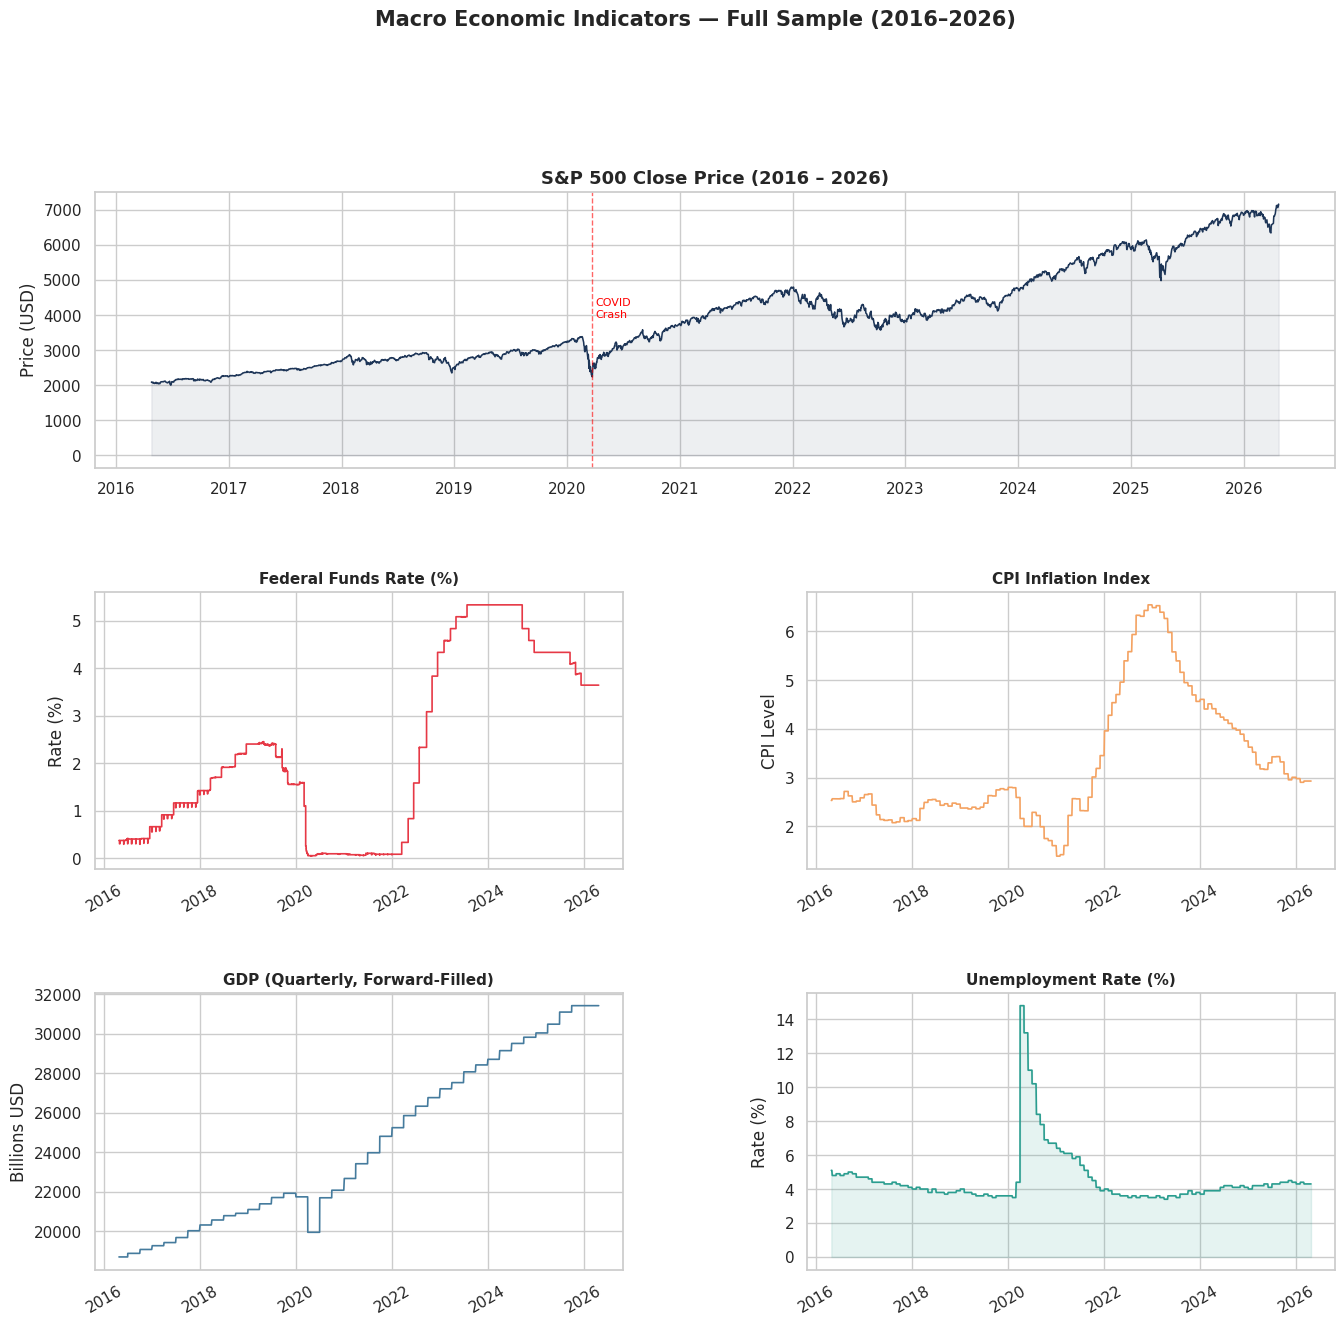

In [ ]:
# Some more potentially useful visualizations

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
MACRO_COLOR = {'fed_rate': '#E63946', 'gdp': '#457B9D',
               'inflation': '#F4A261', 'unemployment': '#2A9D8F'}

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# SPX Close Annotate COVID crash
ax0 = fig.add_subplot(gs[0, :])
ax0.plot(master.index, master['close'], color='#1D3557', linewidth=1.1, label='SPX Close')
ax0.fill_between(master.index, master['close'], alpha=0.08, color='#1D3557')
ax0.set_title('S&P 500 Close Price (2016 – 2026)', fontsize=13, fontweight='bold')
ax0.set_ylabel('Price (USD)')
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax0.xaxis.set_major_locator(mdates.YearLocator())
ax0.axvline(pd.Timestamp('2020-03-23'), color='red', linestyle='--', alpha=0.6, linewidth=1)
ax0.text(pd.Timestamp('2020-04-01'), master['close'].max()*0.55,
         'COVID\nCrash', color='red', fontsize=8)

# Fed Funds Rate
ax1 = fig.add_subplot(gs[1, 0])
ax1.step(master.index, master['fed_rate'], color=MACRO_COLOR['fed_rate'], linewidth=1.2, where='post')
ax1.set_title('Federal Funds Rate (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Rate (%)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(2))

# CPI Inflation
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(master.index, master['inflation'], color=MACRO_COLOR['inflation'], linewidth=1.2)
ax2.set_title('CPI Inflation Index', fontsize=11, fontweight='bold')
ax2.set_ylabel('CPI Level')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))

# GDP
ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(master.index, master['gdp'], color=MACRO_COLOR['gdp'], linewidth=1.2)
ax3.set_title('GDP (Quarterly, Forward-Filled)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Billions USD')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.xaxis.set_major_locator(mdates.YearLocator(2))

# Unemployment
ax4 = fig.add_subplot(gs[2, 1])
ax4.plot(master.index, master['unemployment'], color=MACRO_COLOR['unemployment'], linewidth=1.2)
ax4.fill_between(master.index, master['unemployment'], alpha=0.12, color=MACRO_COLOR['unemployment'])
ax4.set_title('Unemployment Rate (%)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Rate (%)')
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax4.xaxis.set_major_locator(mdates.YearLocator(2))

for ax in [ax1, ax2, ax3, ax4]:
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Macro Economic Indicators — Full Sample (2016–2026)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


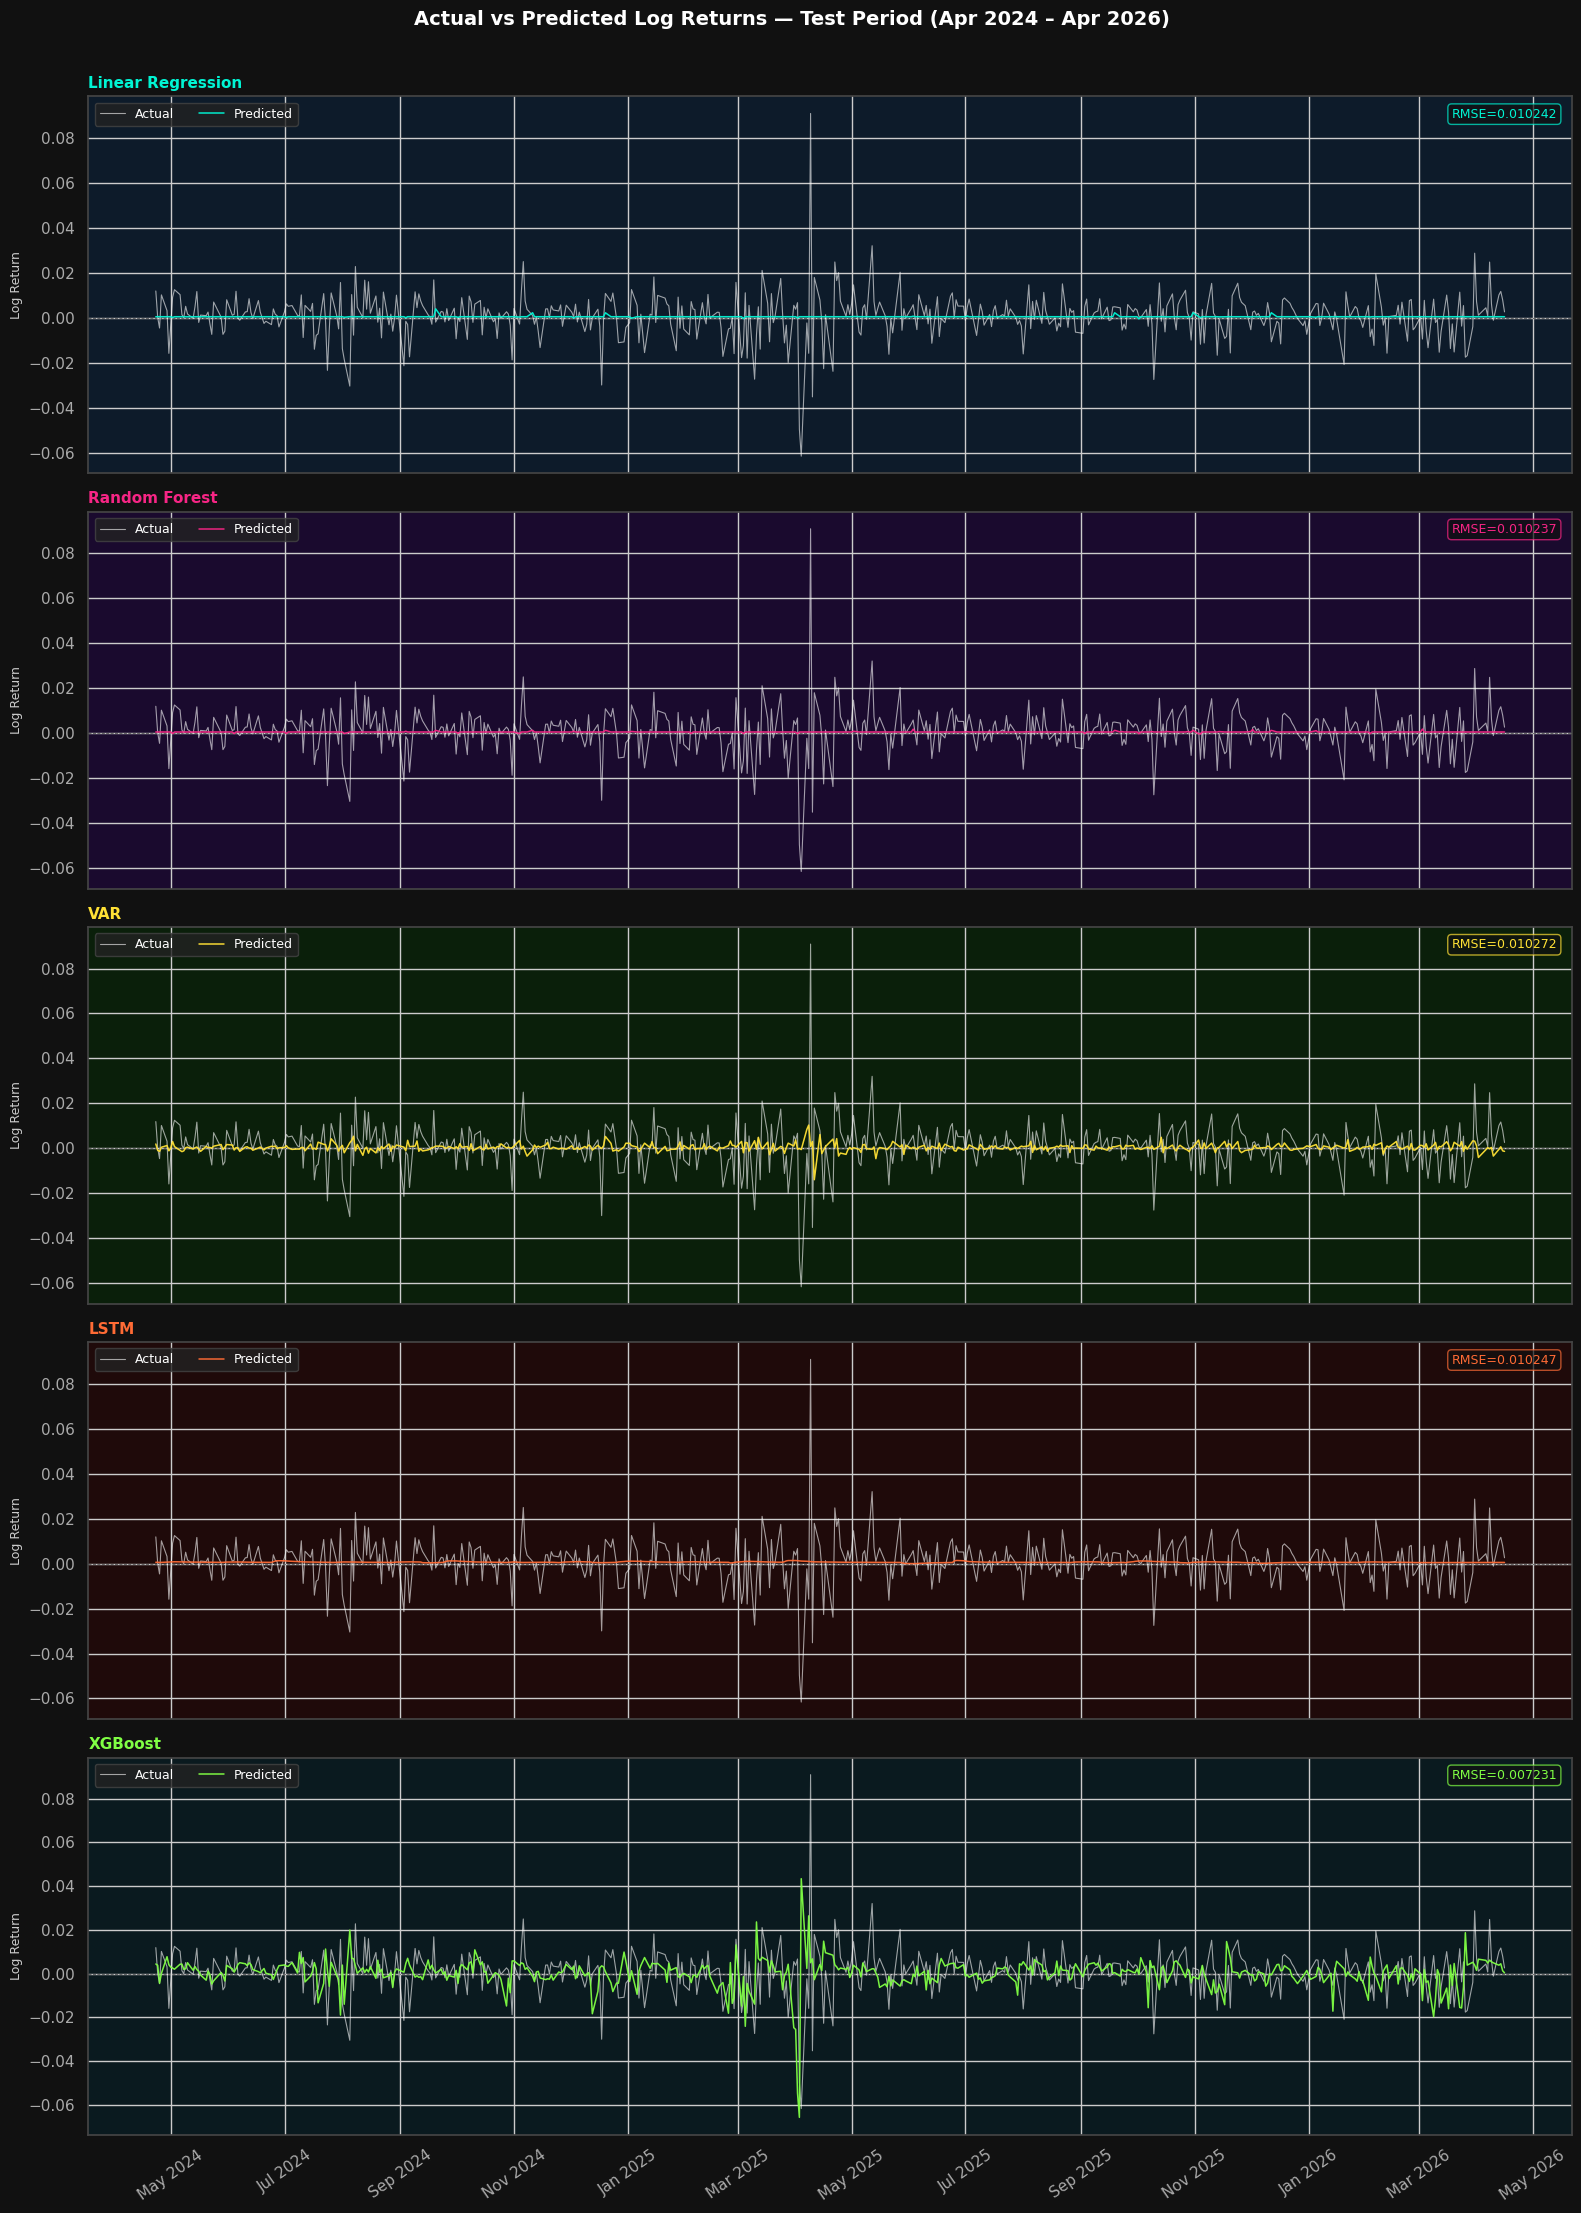

In [ ]:
# We already made these but coloring might be more easy to read

n_overlay = min(len(y_pred_lr), len(y_pred_rf), len(y_pred_var),
                len(y_pred_lstm), len(y_pred_xgb))

dates_overlay  = dates_test[:n_overlay]
actual_overlay = y_true_base[:n_overlay]

preds = {
    'Linear Regression': y_pred_lr[:n_overlay],
    'Random Forest':     y_pred_rf[:n_overlay],
    'VAR':               y_pred_var[:n_overlay],
    'LSTM':              y_pred_lstm[:n_overlay],
    'XGBoost':           y_pred_xgb[:n_overlay],
}


panel_styles = {
    'Linear Regression': {'bg': '#0D1B2A', 'pred': '#00F5D4', 'actual': '#FFFFFF'},  # dark navy / cyan
    'Random Forest':     {'bg': '#1A0A2E', 'pred': '#F72585', 'actual': '#FFFFFF'},  # deep purple / hot pink
    'VAR':               {'bg': '#0A1F0A', 'pred': '#FFE135', 'actual': '#FFFFFF'},  # dark green / yellow
    'LSTM':              {'bg': '#1F0A0A', 'pred': '#FF6B35', 'actual': '#FFFFFF'},  # dark red / orange
    'XGBoost':           {'bg': '#0A1A1F', 'pred': '#80FF44', 'actual': '#FFFFFF'},  # dark teal / lime
}

fig, axes = plt.subplots(5, 1, figsize=(16, 22), sharex=True)
fig.patch.set_facecolor('#111111')
fig.suptitle('Actual vs Predicted Log Returns — Test Period (Apr 2024 – Apr 2026)',
             fontsize=14, fontweight='bold', y=1.005, color='white')

for ax, (name, pred) in zip(axes, preds.items()):
    style = panel_styles[name]

    ax.set_facecolor(style['bg'])
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')

    ax.plot(dates_overlay, actual_overlay,
            color=style['actual'], linewidth=0.8, alpha=0.6, label='Actual',
            zorder=2)
    ax.plot(dates_overlay, pred,
            color=style['pred'], linewidth=1.1, alpha=0.95, label='Predicted',
            zorder=3)
    ax.axhline(0, color='#555555', linewidth=0.6, linestyle='--', zorder=1)

    ax.set_ylabel('Log Return', fontsize=9, color='#CCCCCC')
    ax.tick_params(colors='#AAAAAA')

    legend = ax.legend(fontsize=9, loc='upper left', ncol=2,
                       facecolor='#222222', edgecolor='#444444',
                       labelcolor='white')

    rmse_val = df_metrics_v2.loc[name, 'RMSE'] if name in df_metrics_v2.index else None
    if rmse_val:
        ax.text(0.99, 0.97, f'RMSE={rmse_val:.6f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                color=style['pred'],
                bbox=dict(boxstyle='round', facecolor='#111111', alpha=0.7,
                          edgecolor=style['pred']))

    ax.set_title(name, fontsize=11, fontweight='bold', color=style['pred'], loc='left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

axes[-1].tick_params(axis='x', rotation=35, colors='#AAAAAA')
plt.tight_layout()
plt.show()

/tmp/ipykernel_42981/1348256381.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(res_data, labels=[n.replace(' ', '\n') for n in model_names],


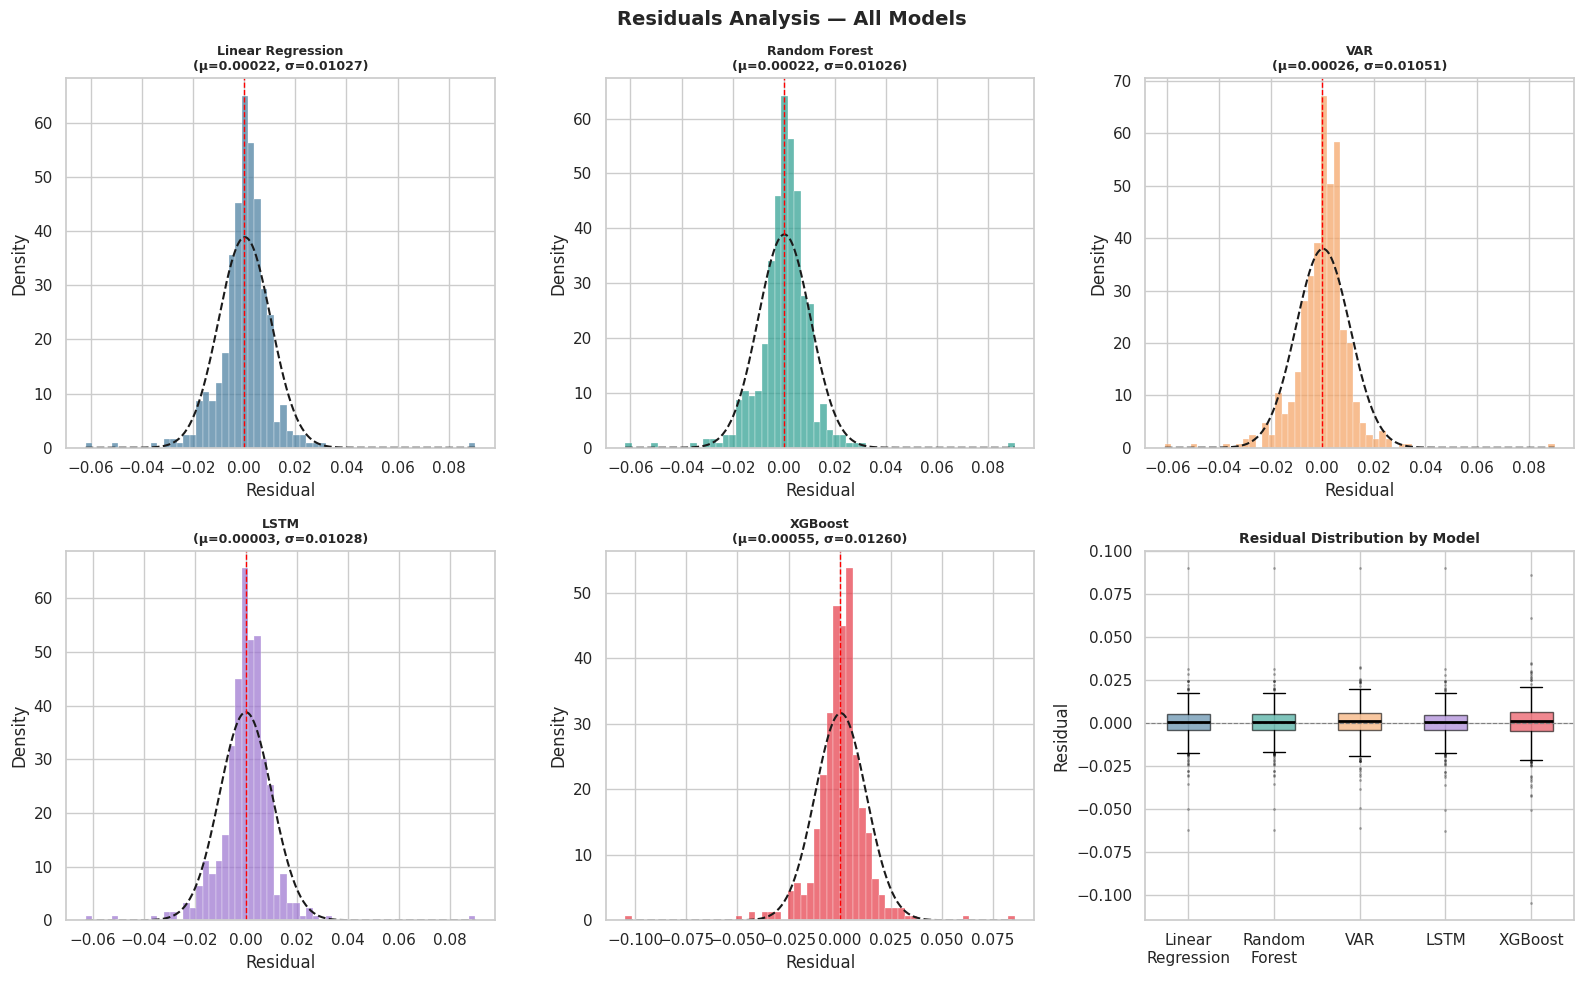

In [ ]:
residuals = {
    'Linear Regression': actual_overlay - y_pred_lr[:n_overlay],
    'Random Forest':     actual_overlay - y_pred_rf[:n_overlay],
    'VAR':               actual_overlay - y_pred_var[:n_overlay],
    'LSTM':              actual_overlay - y_pred_lstm[:n_overlay],
    'XGBoost':           actual_overlay - y_pred_xgb[:n_overlay],
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Residuals Analysis — All Models', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes.flat[:5], residuals.items()):
    color = colors_map[name]
    ax.hist(res, bins=60, color=color, alpha=0.7, edgecolor='white',
            density=True, linewidth=0.3)
    mu_r, sig_r = res.mean(), res.std()
    xr = np.linspace(res.min(), res.max(), 300)
    ax.plot(xr, scipy_stats.norm.pdf(xr, mu_r, sig_r), 'k--', linewidth=1.5)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{name}\n(μ={mu_r:.5f}, σ={sig_r:.5f})',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Residual')
    ax.set_ylabel('Density')

ax_box = axes.flat[5]
res_data = [residuals[n] for n in model_names]
bp = ax_box.boxplot(res_data, labels=[n.replace(' ', '\n') for n in model_names],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax_box.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax_box.set_title('Residual Distribution by Model', fontsize=10, fontweight='bold')
ax_box.set_ylabel('Residual')

plt.tight_layout()
plt.show()